In [24]:
import numpy as np
import pandas as pd

print(pd.__version__)

food = pd.read_csv("D:/Data_Analyst/python/HitMacro_17Sep26_food.csv", encoding="cp1252")
user = pd.read_csv("D:/Data_Analyst/python/HitMacro_17Sep26_user.csv", encoding="cp1252")
food_log = pd.read_csv("D:/Data_Analyst/python/HitMacro_17Sep26_food_log.csv", encoding="cp1252")
daily_summary = pd.read_csv("D:/Data_Analyst/python/HitMacro_17Sep26_daily_summary.csv", encoding="cp1252")
target = pd.read_csv("D:/Data_Analyst/python/HitMacro_17Sep26_target_analysis.csv", encoding="cp1252")

print(food.head())
print(user.head())




3.0.6
  Food id            Food name Dietary type Main source nutrient  \
0    F001  Rice, white, cooked          Veg                 Carb   
1    F002   Brown rice, cooked          Veg                 Carb   
2    F003           Ragi flour          Veg                 Carb   
3    F004          Bajra flour          Veg                 Carb   
4    F005          Jowar flour          Veg                 Carb   

   Protein value (g/100g)  Fat value (g/100g)  Fibre value (g/100g)  \
0                     2.7                 0.3                   0.4   
1                     2.6                 0.9                   1.8   
2                     7.3                 1.3                  11.5   
3                    11.0                 5.0                  11.0   
4                    10.4                 3.1                   6.6   

   Carb value (g/100g)  
0                 28.2  
1                 23.0  
2                 72.0  
3                 67.0  
4                 72.6  
  User_I

In [5]:

target.isnull().sum()



Target_id      0
Target_date    0
User_id        0
Summary_id     0
Protein        0
Fat            0
Fibre          0
carb           0
Calories       0
dtype: int64

In [4]:
food.isnull().sum()


Food id                   0
Food name                 0
Dietary type              0
Main source nutrient      0
Protein value (g/100g)    0
Fat value (g/100g)        0
Fibre value (g/100g)      0
Carb value (g/100g)       0
dtype: int64

In [3]:
user.isnull().sum()


User_ID                   0
Name                      0
Age                       0
Height_cm                 0
Weight_kg                 0
Gender                    0
Calorie_Deficit_Opted     0
BMI                       0
BMR                       0
Activity_level            0
Activity Desc             0
Activity Factor           0
TDEE                      0
Daily_Calorie_Target      0
Daily_Protein_Target_g    0
Daily_Fibre_Target_g      0
Daily_Fat_Target_g        0
Daily_Carb_Target_g       0
dtype: int64

In [6]:
food_log.isnull().sum()


Log_ID                 0
User_ID                0
Food_ID                0
Day_id                 0
Date_Time              0
Meal_Type              0
Quantity_g             0
Total_Protein_g        0
Total_Fat_g            0
Total_Fibre_g          0
Total_Carb_g           0
Total_Calories_kcal    0
dtype: int64

In [7]:
daily_summary.isnull().sum()

Summary_id                    0
Userid                        0
Day_id                        0
date                          0
Total_Protein_g_perday        0
Total_Fat_g_perday            0
Total_Fibre_g_perday          0
Total_Carb_g_perday           0
Total_Calories_kcal_perday    0
dtype: int64

In [71]:
'''food, user ,food_log ,daily_summary ,target'''
'''fixing naming convention'''
'''object food'''
food.columns= food.columns.str.lower()




In [69]:
'''object food_log'''
food_log.columns= food_log.columns.str.lower()

In [72]:
'''object user'''
user.columns= user.columns.str.lower()

In [73]:
'''object target'''
target.columns= target.columns.str.lower()

In [74]:
'''object daily summary'''
daily_summary.columns= daily_summary.columns.str.lower()

In [ ]:
%pip install mysql-connector-python

In [44]:
print("Python is working!")

Python is working!


In [48]:
import mysql.connector
print("mysql connector imported")

mysql connector imported


In [ ]:
conn = mysql.connector.connect(
    host="***********",
    user="***********",
    password="***********",
    database="***********",
    port=3308
)

print("Connected successfully!")

Connected successfully!


In [50]:
print(conn.is_connected())

True


In [51]:
cursor = conn.cursor()
cursor.execute("SHOW DATABASES")

for db in cursor:
    print(db)

('hitmacro2026',)
('information_schema',)
('mysql',)
('performance_schema',)
('sys',)
('world',)


In [52]:
query = "SELECT * FROM Users"
df = pd.read_sql(query, conn)
print(df.head())

  User_ID         Name  Age  Height_cm  Weight_kg  Gender  \
0   HM001     Abilasha   30      152.0       60.0  Female   
1   HM002       Sindhu   30      152.0       60.0  Female   
2   HM003       Sundar   28      165.0       68.0    Male   
3   HM004       Sanjay   28      165.0       68.0    Male   
4   HM005  Manudheeran    5      110.0       19.0    Male   

  Calorie_Deficit_Opted     Activity_Level                     Activity_Desc  \
0                     Y  Moderately active            exercise 3–5 days/week   
1                     Y     Lightly active            exercise 1–3 days/week   
2                     Y  Moderately active            exercise 3–5 days/week   
3                     Y        Very active            exercise 6–7 days/week   
4                     N   Extremely active   very hard training/physical job   

   Activity_Factor       TDEE  Daily_Calorie_Target  Daily_Protein_Target_g  \
0             1.55  1920.4500                  1536                    85

C:\Users\hp\AppData\Local\Temp\ipykernel_6572\3063470651.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [53]:
df["Height_m"] = df["Height_cm"] / 100

df["BMI"] = df["Weight_kg"] / (df["Height_m"] ** 2)

df["BMI"] = df["BMI"].round(2)

print(df[["Weight_kg", "Height_cm", "Height_m", "BMI"]].head())

   Weight_kg  Height_cm  Height_m    BMI
0       60.0      152.0      1.52  25.97
1       60.0      152.0      1.52  25.97
2       68.0      165.0      1.65  24.98
3       68.0      165.0      1.65  24.98
4       19.0      110.0      1.10  15.70


In [54]:
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df["BMI_Category"] = df["BMI"].apply(bmi_category)

   

In [55]:
print(df[["BMI", "BMI_Category"]].head())

     BMI BMI_Category
0  25.97   Overweight
1  25.97   Overweight
2  24.98       Normal
3  24.98       Normal
4  15.70  Underweight


In [23]:
print(df[["Name", "Weight_kg", "Height_cm", "BMI", "BMI_Category"]].head(10))

          Name  Weight_kg  Height_cm    BMI BMI_Category
0     Abilasha       60.0      152.0  25.97   Overweight
1       Sindhu       60.0      152.0  25.97   Overweight
2       Sundar       68.0      165.0  24.98       Normal
3       Sanjay       68.0      165.0  24.98       Normal
4  Manudheeran       19.0      110.0  15.70  Underweight
5     Mathimei       18.0      108.0  15.43  Underweight
6       Oviyan       19.0      109.0  15.99  Underweight
7       Vijaya       68.0      155.0  28.30   Overweight
8        Sekar       67.0      160.0  26.17   Overweight
9    Sudharsan       70.0      170.0  24.22       Normal


In [56]:
'''BMI'''
bmi_result = df[[
    "Name",
    "Weight_kg",
    "Height_cm",
    "BMI",
    "BMI_Category"
]]

print(bmi_result)

           Name  Weight_kg  Height_cm    BMI BMI_Category
0      Abilasha       60.0      152.0  25.97   Overweight
1        Sindhu       60.0      152.0  25.97   Overweight
2        Sundar       68.0      165.0  24.98       Normal
3        Sanjay       68.0      165.0  24.98       Normal
4   Manudheeran       19.0      110.0  15.70  Underweight
5      Mathimei       18.0      108.0  15.43  Underweight
6        Oviyan       19.0      109.0  15.99  Underweight
7        Vijaya       68.0      155.0  28.30   Overweight
8         Sekar       67.0      160.0  26.17   Overweight
9     Sudharsan       70.0      170.0  24.22       Normal
10    Suganthan       78.0      175.0  25.47   Overweight
11     Dharshan       65.0      164.0  24.17       Normal
12       Subeth       68.0      170.0  23.53       Normal
13  Pattu Rajan       54.0      154.0  22.77       Normal
14     Rajammal       50.0      150.0  22.22       Normal
15  Valli ammai       48.0      152.0  20.78       Normal
16    Muthaiya

In [57]:
'''Mifflin–St Jeor formula'''
def calculate_bmr(row):
    if row["Gender"].lower() == "female":
        return (10 * row["Weight_kg"]) + (6.25 * row["Height_cm"]) - (5 * row["Age"]) - 161
    else:
        return (10 * row["Weight_kg"]) + (6.25 * row["Height_cm"]) - (5 * row["Age"]) + 5

df["BMR"] = df.apply(calculate_bmr, axis=1)

df["BMR"] = df["BMR"].round(2)

print(df[["Name", "Weight_kg", "Height_cm", "Age", "Gender", "BMR"]])

           Name  Weight_kg  Height_cm  Age  Gender      BMR
0      Abilasha       60.0      152.0   30  Female  1239.00
1        Sindhu       60.0      152.0   30  Female  1239.00
2        Sundar       68.0      165.0   28    Male  1576.25
3        Sanjay       68.0      165.0   28    Male  1576.25
4   Manudheeran       19.0      110.0    5    Male   857.50
5      Mathimei       18.0      108.0    5  Female   669.00
6        Oviyan       19.0      109.0    5    Male   851.25
7        Vijaya       68.0      155.0   55  Female  1212.75
8         Sekar       67.0      160.0   63    Male  1360.00
9     Sudharsan       70.0      170.0   34    Male  1597.50
10    Suganthan       78.0      175.0   27    Male  1743.75
11     Dharshan       65.0      164.0   14    Male  1610.00
12       Subeth       68.0      170.0   32    Male  1587.50
13  Pattu Rajan       54.0      154.0   97    Male  1022.50
14     Rajammal       50.0      150.0   96  Female   796.50
15  Valli ammai       48.0      152.0   

In [58]:
print(df[[
    "Name",
    "BMR",
    "Activity_Level",
    "Activity_Desc",
    "Activity_Factor"
]].head(10))

          Name      BMR     Activity_Level                     Activity_Desc  \
0     Abilasha  1239.00  Moderately active            exercise 3–5 days/week   
1       Sindhu  1239.00     Lightly active            exercise 1–3 days/week   
2       Sundar  1576.25  Moderately active            exercise 3–5 days/week   
3       Sanjay  1576.25        Very active            exercise 6–7 days/week   
4  Manudheeran   857.50   Extremely active   very hard training/physical job   
5     Mathimei   669.00  Moderately active                little/no exercise   
6       Oviyan   851.25  Moderately active                little/no exercise   
7       Vijaya  1212.75          Sedentary                little/no exercise   
8        Sekar  1360.00          Sedentary                little/no exercise   
9    Sudharsan  1597.50  Moderately active                little/no exercise   

   Activity_Factor  
0             1.55  
1             1.38  
2             1.55  
3             1.73  
4             

In [59]:
df["TDEE"] = df["BMR"] * df["Activity_Factor"]
print(df[[
    "Name",
    "BMR",
    "Activity_Level",
    "Activity_Desc",
    "Activity_Factor",
    "TDEE"
]])

           Name      BMR     Activity_Level                     Activity_Desc  \
0      Abilasha  1239.00  Moderately active            exercise 3–5 days/week   
1        Sindhu  1239.00     Lightly active            exercise 1–3 days/week   
2        Sundar  1576.25  Moderately active            exercise 3–5 days/week   
3        Sanjay  1576.25        Very active            exercise 6–7 days/week   
4   Manudheeran   857.50   Extremely active   very hard training/physical job   
5      Mathimei   669.00  Moderately active                little/no exercise   
6        Oviyan   851.25  Moderately active                little/no exercise   
7        Vijaya  1212.75          Sedentary                little/no exercise   
8         Sekar  1360.00          Sedentary                little/no exercise   
9     Sudharsan  1597.50  Moderately active                little/no exercise   
10    Suganthan  1743.75  Moderately active            exercise 3–5 days/week   
11     Dharshan  1610.00   E

In [60]:
print(df[[
    "Name",
    "Calorie_Deficit_Opted",
    "TDEE"
]].head(10))

          Name Calorie_Deficit_Opted       TDEE
0     Abilasha                     Y  1920.4500
1       Sindhu                     Y  1709.8200
2       Sundar                     Y  2443.1875
3       Sanjay                     Y  2726.9125
4  Manudheeran                     N  1629.2500
5     Mathimei                     N  1036.9500
6       Oviyan                     N  1319.4375
7       Vijaya                     Y  1455.3000
8        Sekar                     Y  1632.0000
9    Sudharsan                     N  2476.1250


In [61]:
df["Daily_Calorie_Target"] = df.apply(
    lambda row: row["TDEE"] - (row["TDEE"] * 20 / 100)
    if row["Calorie_Deficit_Opted"] == "Y"
    else row["TDEE"],
    axis=1
)

df["Daily_Calorie_Target"] = df["Daily_Calorie_Target"].round(0)

print(df[[
    "Name",
    "TDEE",
    "Calorie_Deficit_Opted",
    "Daily_Calorie_Target"
]])

           Name       TDEE Calorie_Deficit_Opted  Daily_Calorie_Target
0      Abilasha  1920.4500                     Y                1536.0
1        Sindhu  1709.8200                     Y                1368.0
2        Sundar  2443.1875                     Y                1955.0
3        Sanjay  2726.9125                     Y                2182.0
4   Manudheeran  1629.2500                     N                1629.0
5      Mathimei  1036.9500                     N                1037.0
6        Oviyan  1319.4375                     N                1319.0
7        Vijaya  1455.3000                     Y                1164.0
8         Sekar  1632.0000                     Y                1306.0
9     Sudharsan  2476.1250                     N                2476.0
10    Suganthan  2702.8125                     Y                2162.0
11     Dharshan  3059.0000                     Y                2447.0
12       Subeth  2460.6250                     N                2461.0
13  Pa

In [62]:
print(df[[
    "Name",
    "Activity_Level",
    "Daily_Calorie_Target"
]].head(10))

          Name     Activity_Level  Daily_Calorie_Target
0     Abilasha  Moderately active                1536.0
1       Sindhu     Lightly active                1368.0
2       Sundar  Moderately active                1955.0
3       Sanjay        Very active                2182.0
4  Manudheeran   Extremely active                1629.0
5     Mathimei  Moderately active                1037.0
6       Oviyan  Moderately active                1319.0
7       Vijaya          Sedentary                1164.0
8        Sekar          Sedentary                1306.0
9    Sudharsan  Moderately active                2476.0


In [63]:
'''protein target calculation'''
def calculate_protein(row):
    activity = row["Activity_Level"].strip().lower()
    calories = row["Daily_Calorie_Target"]

    if activity in ["lightly active", "moderately active"]:
        return (calories * 25 / 100) / 4

    elif activity in ["very active", "extremely active"]:
        return (calories * 35 / 100) / 4

    elif activity == "sedentary":
        return (calories * 30 / 100) / 4

    else:
        return 0

df["Daily_Protein_Target"] = df.apply(calculate_protein, axis=1)
df["Daily_Protein_Target"] = df["Daily_Protein_Target"].round(0)

print(df[[
    "Name",
    "Activity_Level",
    "Daily_Calorie_Target",
    "Daily_Protein_Target"
]])


           Name     Activity_Level  Daily_Calorie_Target  Daily_Protein_Target
0      Abilasha  Moderately active                1536.0                  96.0
1        Sindhu     Lightly active                1368.0                  86.0
2        Sundar  Moderately active                1955.0                 122.0
3        Sanjay        Very active                2182.0                 191.0
4   Manudheeran   Extremely active                1629.0                 143.0
5      Mathimei  Moderately active                1037.0                  65.0
6        Oviyan  Moderately active                1319.0                  82.0
7        Vijaya          Sedentary                1164.0                  87.0
8         Sekar          Sedentary                1306.0                  98.0
9     Sudharsan  Moderately active                2476.0                 155.0
10    Suganthan  Moderately active                2162.0                 135.0
11     Dharshan   Extremely active                24

In [64]:
df["Daily_Fibre_Target"] = df["Daily_Calorie_Target"] / 1000 * 14
df["Daily_Fibre_Target"] = df["Daily_Fibre_Target"].round(0)

print(df[[
    "Name",
    "Daily_Calorie_Target",
    "Daily_Fibre_Target"
]])

           Name  Daily_Calorie_Target  Daily_Fibre_Target
0      Abilasha                1536.0                22.0
1        Sindhu                1368.0                19.0
2        Sundar                1955.0                27.0
3        Sanjay                2182.0                31.0
4   Manudheeran                1629.0                23.0
5      Mathimei                1037.0                15.0
6        Oviyan                1319.0                18.0
7        Vijaya                1164.0                16.0
8         Sekar                1306.0                18.0
9     Sudharsan                2476.0                35.0
10    Suganthan                2162.0                30.0
11     Dharshan                2447.0                34.0
12       Subeth                2461.0                34.0
13  Pattu Rajan                1227.0                17.0
14     Rajammal                 956.0                13.0
15  Valli ammai                1085.0                15.0
16    Muthaiya

In [65]:
def calculate_fat(row):
    activity = row["Activity_Level"].strip().lower()
    calories = row["Daily_Calorie_Target"]

    if activity in ["lightly active", "moderately active"]:
        return (calories * 25 / 100) / 9

    elif activity in ["very active", "extremely active"]:
        return (calories * 35 / 100) / 9

    elif activity == "sedentary":
        return (calories * 30 / 100) / 9

    else:
        return 0

df["Daily_Fat_Target"] = df.apply(calculate_fat, axis=1)

df["Daily_Fat_Target"] = df["Daily_Fat_Target"].round(0)

print(df[[
    "Name",
    "Activity_Level",
    "Daily_Calorie_Target",
    "Daily_Fat_Target"
]])

           Name     Activity_Level  Daily_Calorie_Target  Daily_Fat_Target
0      Abilasha  Moderately active                1536.0              43.0
1        Sindhu     Lightly active                1368.0              38.0
2        Sundar  Moderately active                1955.0              54.0
3        Sanjay        Very active                2182.0              85.0
4   Manudheeran   Extremely active                1629.0              63.0
5      Mathimei  Moderately active                1037.0              29.0
6        Oviyan  Moderately active                1319.0              37.0
7        Vijaya          Sedentary                1164.0              39.0
8         Sekar          Sedentary                1306.0              44.0
9     Sudharsan  Moderately active                2476.0              69.0
10    Suganthan  Moderately active                2162.0              60.0
11     Dharshan   Extremely active                2447.0              95.0
12       Subeth  Moderate

In [66]:
def calculate_carbs(row):
    activity = row["Activity_Level"].strip().lower()
    calories = row["Daily_Calorie_Target"]

    if activity in ["lightly active", "moderately active"]:
        return (calories * 25 / 100) / 4

    elif activity in ["very active", "extremely active"]:
        return (calories * 35 / 100) / 4

    elif activity == "sedentary":
        return (calories * 30 / 100) / 4

    else:
        return 0

df["Daily_Carb_Target"] = df.apply(calculate_carbs, axis=1)
df["Daily_Carb_Target"] = df["Daily_Carb_Target"].round(0)

print(df[[
    "Name",
    "Activity_Level",
    "Daily_Calorie_Target",
    "Daily_Carb_Target"
]])

           Name     Activity_Level  Daily_Calorie_Target  Daily_Carb_Target
0      Abilasha  Moderately active                1536.0               96.0
1        Sindhu     Lightly active                1368.0               86.0
2        Sundar  Moderately active                1955.0              122.0
3        Sanjay        Very active                2182.0              191.0
4   Manudheeran   Extremely active                1629.0              143.0
5      Mathimei  Moderately active                1037.0               65.0
6        Oviyan  Moderately active                1319.0               82.0
7        Vijaya          Sedentary                1164.0               87.0
8         Sekar          Sedentary                1306.0               98.0
9     Sudharsan  Moderately active                2476.0              155.0
10    Suganthan  Moderately active                2162.0              135.0
11     Dharshan   Extremely active                2447.0              214.0
12       Sub

In [67]:
print(df[[
    "Name",
    "BMI",
    "BMR",
    "TDEE",
    "Daily_Calorie_Target",
    "Daily_Protein_Target",
    "Daily_Fibre_Target",
    "Daily_Fat_Target",
    "Daily_Carb_Target"
]])

           Name    BMI      BMR       TDEE  Daily_Calorie_Target  \
0      Abilasha  25.97  1239.00  1920.4500                1536.0   
1        Sindhu  25.97  1239.00  1709.8200                1368.0   
2        Sundar  24.98  1576.25  2443.1875                1955.0   
3        Sanjay  24.98  1576.25  2726.9125                2182.0   
4   Manudheeran  15.70   857.50  1629.2500                1629.0   
5      Mathimei  15.43   669.00  1036.9500                1037.0   
6        Oviyan  15.99   851.25  1319.4375                1319.0   
7        Vijaya  28.30  1212.75  1455.3000                1164.0   
8         Sekar  26.17  1360.00  1632.0000                1306.0   
9     Sudharsan  24.22  1597.50  2476.1250                2476.0   
10    Suganthan  25.47  1743.75  2702.8125                2162.0   
11     Dharshan  24.17  1610.00  3059.0000                2447.0   
12       Subeth  23.53  1587.50  2460.6250                2461.0   
13  Pattu Rajan  22.77  1022.50  1227.0000      

In [75]:
print(food_log[[
    "food_id",
    "quantity_g"
]].head())



  food_id  quantity_g
0    F014         110
1    F472          80
2    F276           5
3    F247         135
4    F206           5


In [76]:
print(food.head())

  food id            food name dietary type main source nutrient  \
0    F001  Rice, white, cooked          Veg                 Carb   
1    F002   Brown rice, cooked          Veg                 Carb   
2    F003           Ragi flour          Veg                 Carb   
3    F004          Bajra flour          Veg                 Carb   
4    F005          Jowar flour          Veg                 Carb   

   protein value (g/100g)  fat value (g/100g)  fibre value (g/100g)  \
0                     2.7                 0.3                   0.4   
1                     2.6                 0.9                   1.8   
2                     7.3                 1.3                  11.5   
3                    11.0                 5.0                  11.0   
4                    10.4                 3.1                   6.6   

   carb value (g/100g)  
0                 28.2  
1                 23.0  
2                 72.0  
3                 67.0  
4                 72.6  


In [77]:
print(food_log.columns.tolist())
print(food.columns.tolist())

['log_id', 'user_id', 'food_id', 'day_id', 'date_time', 'meal_type', 'quantity_g', 'total_protein_g', 'total_fat_g', 'total_fibre_g', 'total_carb_g', 'total_calories_kcal']
['food id', 'food name', 'dietary type', 'main source nutrient', 'protein value (g/100g)', 'fat value (g/100g)', 'fibre value (g/100g)', 'carb value (g/100g)']


In [78]:
food_log = food_log.merge(
    food[["food id", "protein value (g/100g)","fat value (g/100g)","fibre value (g/100g)","carb value (g/100g)"]],
    left_on="food_id",
    right_on="food id",
    how="left"
)

In [79]:
food_log["Total_Protein_g"] = (
    food_log["quantity_g"] / 100
) * food_log["protein value (g/100g)"]

'''food_log["Total_Protein_g"] = food_log["Total_Protein_g"].round(0)'''

print(food_log[[
    "food_id",
    "quantity_g",
    "protein value (g/100g)",
    "Total_Protein_g"
]])

     food_id  quantity_g  protein value (g/100g)  Total_Protein_g
0       F014         110                     7.2            7.920
1       F472          80                     7.3            5.840
2       F276           5                     7.4            0.370
3       F247         135                     0.9            1.215
4       F206           5                    10.8            0.540
...      ...         ...                     ...              ...
6214    F123          85                     1.1            0.935
6215    F191          35                     2.6            0.910
6216    F239          15                    26.0            3.900
6217    F178         345                     2.4            8.280
6218    F218          20                     8.3            1.660

[6219 rows x 4 columns]


In [80]:
food_log["Total_Fat_g"] = (
    food_log["quantity_g"] / 100
) * food_log["fat value (g/100g)"]

'''food_log["Total_Fat_g"] = food_log["Total_Fat_g"].round(0)'''

print(food_log[[
    "food_id",
    "quantity_g",
    "fat value (g/100g)",
    "Total_Fat_g"
]])

     food_id  quantity_g  fat value (g/100g)  Total_Fat_g
0       F014         110                 1.0        1.100
1       F472          80                 1.3        1.040
2       F276           5                 1.1        0.055
3       F247         135                 0.2        0.270
4       F206           5                 3.2        0.160
...      ...         ...                 ...          ...
6214    F123          85                 0.3        0.255
6215    F191          35                 1.0        0.350
6216    F239          15                11.4        1.710
6217    F178         345                 0.4        1.380
6218    F218          20                 0.6        0.120

[6219 rows x 4 columns]


In [81]:
print(food_log.columns.tolist())

['log_id', 'user_id', 'food_id', 'day_id', 'date_time', 'meal_type', 'quantity_g', 'total_protein_g', 'total_fat_g', 'total_fibre_g', 'total_carb_g', 'total_calories_kcal', 'food id', 'protein value (g/100g)', 'fat value (g/100g)', 'fibre value (g/100g)', 'carb value (g/100g)', 'Total_Protein_g', 'Total_Fat_g']


In [ ]:
food_log["Total_Fibre_g"] = (
    food_log["quantity_g"] / 100
) * food_log["fibre value (g/100g)_y"]

In [85]:
print(food_log[[
    "food_id",
    "quantity_g",
    "fibre value (g/100g)_y",
    "Total_Fibre_g"
]])

     food_id  quantity_g  fibre value (g/100g)_y  Total_Fibre_g
0       F014         110                     5.1          5.610
1       F472          80                    11.5          9.200
2       F276           5                     1.0          0.050
3       F247         135                     2.8          3.780
4       F206           5                     6.6          0.330
...      ...         ...                     ...            ...
6214    F123          85                     2.6          2.210
6215    F191          35                     5.4          1.890
6216    F239          15                     0.0          0.000
6217    F178         345                     3.3         11.385
6218    F218          20                     5.0          1.000

[6219 rows x 4 columns]


In [83]:
food_log["Total_Carb_g"] = (
    food_log["quantity_g"] / 100
) * food_log["carb value (g/100g)"]

'''food_log["Total_Carb_g"] = food_log["Total_Carb_g"].round(0)'''

print(food_log[[
    "food_id",
    "quantity_g",
    "carb value (g/100g)",
    "Total_Carb_g"
]])



     food_id  quantity_g  carb value (g/100g)  Total_Carb_g
0       F014         110                 20.0        22.000
1       F472          80                 72.0        57.600
2       F276           5                 80.9         4.045
3       F247         135                 10.0        13.500
4       F206           5                 75.5         3.775
...      ...         ...                  ...           ...
6214    F123          85                 22.3        18.955
6215    F191          35                 14.2         4.970
6216    F239          15                  0.0         0.000
6217    F178         345                  7.1        24.495
6218    F218          20                 20.8         4.160

[6219 rows x 4 columns]


In [84]:
food_log["Total_Calories_kcal"] = (
    (food_log["total_protein_g"] * 4)
    + (food_log["total_carb_g"] * 4)
    + (food_log["total_fat_g"] * 9)
)

'''food_log["Total_Calories_kcal"] = food_log["Total_Calories_kcal"].round(0)'''

'food_log["Total_Calories_kcal"] = food_log["Total_Calories_kcal"].round(0)'

In [85]:
print(food_log[[
    "food_id",
    "user_id",
    "total_protein_g",
    "total_carb_g",
    "total_fat_g",
    "total_calories_kcal"
]])

     food_id user_id  total_protein_g  total_carb_g  total_fat_g  \
0       F014   HM001            8.000        22.000        1.000   
1       F472   HM001            6.000        58.000        1.000   
2       F276   HM001            0.000         4.000        0.000   
3       F247   HM001            1.000        14.000        0.000   
4       F206   HM001            1.000         4.000        0.000   
...      ...     ...              ...           ...          ...   
6214    F123   HM017            0.935        18.955        0.255   
6215    F191   HM017            0.910         4.970        0.350   
6216    F239   HM017            3.900         0.000        1.710   
6217    F178   HM017            8.280        24.495        1.380   
6218    F218   HM017            1.660         4.160        0.120   

      total_calories_kcal  
0                 130.000  
1                 263.000  
2                  18.000  
3                  61.000  
4                  19.000  
...            

In [91]:
print(daily_summary.columns.tolist())

['summary_id', 'userid', 'day_id', 'date', 'total_protein_g_perday', 'total_fat_g_perday', 'total_fibre_g_perday', 'total_carb_g_perday', 'total_calories_kcal_perday']


In [93]:
print(daily_summary.columns.tolist())
print(food_log.columns.tolist())

['summary_id', 'userid', 'day_id', 'date', 'total_protein_g_perday', 'total_fat_g_perday', 'total_fibre_g_perday', 'total_carb_g_perday', 'total_calories_kcal_perday']
['log_id', 'user_id', 'food_id', 'day_id', 'date_time', 'meal_type', 'quantity_g', 'total_protein_g', 'total_fat_g', 'total_fibre_g', 'total_carb_g', 'total_calories_kcal', 'food id_x', 'protein value (g/100g)_x', 'fat value (g/100g)_x', 'total_fat_g', 'food id_y', 'protein value (g/100g)_y', 'fat value (g/100g)_y', 'fibre value (g/100g)_x', 'total_fibre_g', 'food id', 'protein value (g/100g)', 'fat value (g/100g)', 'fibre value (g/100g)_y', 'carb value (g/100g)', 'total_carb_g', 'total_calories_kcal', 'total_protein_g', 'calories_check', 'Total_Fibre_g']


In [86]:
food_log.columns = food_log.columns.str.strip().str.lower()
daily_summary.columns = daily_summary.columns.str.strip().str.lower()

In [104]:

print(food_log.columns.tolist())

['log_id', 'user_id', 'food_id', 'day_id', 'date_time', 'meal_type', 'quantity_g', 'total_protein_g', 'total_fat_g', 'total_fibre_g', 'total_carb_g', 'total_calories_kcal', 'food id_x', 'protein value (g/100g)_x', 'fat value (g/100g)_x', 'food id_y', 'protein value (g/100g)_y', 'fat value (g/100g)_y', 'fibre value (g/100g)_x', 'food id', 'protein value (g/100g)', 'fat value (g/100g)', 'fibre value (g/100g)_y', 'carb value (g/100g)', 'calories_check']


In [87]:
'''Daily_summary formulas'''

fat_summary = (
    food_log.groupby(["user_id", "day_id"])["total_fat_g"]
    .sum()
)

daily_summary["Total_Fat_g_perday"] = (
    daily_summary.set_index(["user_id", "day_id"])
    .index.map(fat_summary)
    .fillna(0)
)

KeyError: "None of ['user_id'] are in the columns"

In [88]:
duplicates = food_log.columns[food_log.columns.duplicated()].tolist()

print("Duplicate columns:")
print(duplicates)

for col in food_log.columns:
    print(col)

Duplicate columns:
['total_protein_g', 'total_fat_g', 'total_carb_g', 'total_calories_kcal']
log_id
user_id
food_id
day_id
date_time
meal_type
quantity_g
total_protein_g
total_fat_g
total_fibre_g
total_carb_g
total_calories_kcal
food id
protein value (g/100g)
fat value (g/100g)
fibre value (g/100g)
carb value (g/100g)
total_protein_g
total_fat_g
total_carb_g
total_calories_kcal


In [98]:
duplicate_names = [
    col for col in food_log.columns
    if food_log.columns.tolist().count(col) > 1
]

print(set(duplicate_names))

{'total_protein_g', 'total_calories_kcal', 'total_carb_g', 'total_fibre_g', 'total_fat_g'}


In [100]:
print(food_log.loc[:, food_log.columns == "total_fat_g"].head(10))
print(food_log.loc[:, food_log.columns == "total_fibre_g"].head(10))
print(food_log.loc[:, food_log.columns == "total_carb_g"].head(10))
print(food_log.loc[:, food_log.columns == "total_calories_kcal"].head(10))
print(food_log.loc[:, food_log.columns == "total_protein_g"].head(10))

   total_fat_g  total_fat_g
0          1.0        1.100
1          1.0        1.040
2          0.0        0.055
3          0.0        0.270
4          0.0        0.160
5          0.0        0.420
6          2.0        1.520
7          1.0        1.480
8          0.0        0.150
9          0.0        0.420
   total_fibre_g  total_fibre_g  total_fibre_g
0            6.0           5.61          5.610
1            9.0           9.20          9.200
2            0.0           0.05          0.050
3            4.0           3.78          3.780
4            0.0           0.33          0.330
5            3.0           3.01          3.010
6            0.0           0.00          0.000
7            0.0           0.00          0.000
8            1.0           0.75          0.750
9            8.0           8.30          8.295
   total_carb_g  total_carb_g
0          22.0        22.000
1          58.0        57.600
2           4.0         4.045
3          14.0        13.500
4           4.0         3

In [89]:
from collections import Counter

def make_unique_columns(df):
    counts = Counter()
    new_columns = []

    for col in df.columns:
        counts[col] += 1

        if counts[col] == 1:
            new_columns.append(col)
        else:
            new_columns.append(f"{col}_{counts[col]}")

    df = df.copy()
    df.columns = new_columns
    return df

food_log = make_unique_columns(food_log)
print(food_log.columns.tolist())

['log_id', 'user_id', 'food_id', 'day_id', 'date_time', 'meal_type', 'quantity_g', 'total_protein_g', 'total_fat_g', 'total_fibre_g', 'total_carb_g', 'total_calories_kcal', 'food id', 'protein value (g/100g)', 'fat value (g/100g)', 'fibre value (g/100g)', 'carb value (g/100g)', 'total_protein_g_2', 'total_fat_g_2', 'total_carb_g_2', 'total_calories_kcal_2']


In [ ]:
# Keep the calculated nutrition values
food_log["total_protein_g"] = food_log["total_protein_g_2"]
food_log["total_fat_g"] = food_log["total_fat_g_2"]
food_log["total_fibre_g"] = food_log["total_fibre_g_3"]
food_log["total_carb_g"] = food_log["total_carb_g_2"]
food_log["total_calories_kcal"] = food_log["total_calories_kcal_2"]


# Remove duplicate/redundant calculation columns
food_log = food_log.drop(columns=[
    "total_protein_g_2",
    "total_fat_g_2",
    "total_fibre_g_2",
    "total_fibre_g_3",
    "total_carb_g_2",
    "total_calories_kcal_2"
])

In [91]:
print(food_log[
    [
        "quantity_g",
        "total_protein_g",
        "total_fat_g",
        "total_fibre_g",
        "total_carb_g",
        "total_calories_kcal"
    ]
].head(10))

   quantity_g  total_protein_g  total_fat_g  total_fibre_g  total_carb_g  \
0         110            7.920        1.100            6.0          22.0   
1          80            5.840        1.040            9.0          58.0   
2           5            0.370        0.055            0.0           4.0   
3         135            1.215        0.270            4.0          14.0   
4           5            0.540        0.160            0.0           4.0   
5          70            0.630        0.420            3.0           7.0   
6          40           13.040        1.520            0.0           0.0   
7          40           12.640        1.480            0.0           0.0   
8         150            1.050        0.150            1.0           5.0   
9         105            9.450        0.420            8.0          21.0   

   total_calories_kcal  
0                130.0  
1                263.0  
2                 18.0  
3                 61.0  
4                 19.0  
5            

In [92]:
'''Daily summary Calculations'''

nutrition_summary = (
    food_log
    .groupby(["user_id", "day_id"], as_index=False)
    .agg({
        "total_protein_g": "sum",
        "total_fat_g": "sum",
        "total_fibre_g": "sum",
        "total_carb_g": "sum",
        "total_calories_kcal": "sum"
    })
    .rename(columns={
        "total_protein_g": "Total_Protein_g_perday",
        "total_fat_g": "Total_Fat_g_perday",
        "total_fibre_g": "Total_Fibre_g_perday",
        "total_carb_g": "Total_Carb_g_perday",
        "total_calories_kcal": "Total_Calories_kcal_perday"
    })
)

# Remove existing calculated columns before merging
daily_summary = daily_summary.drop(
    columns=[
        "Total_Protein_g_perday",
        "Total_Fat_g_perday",
        "Total_Fibre_g_perday",
        "Total_Carb_g_perday",
        "Total_Calories_kcal_perday"
    ],
    errors="ignore"
)

# Merge using userid in daily_summary and user_id in food_log
daily_summary = daily_summary.merge(
    nutrition_summary,
    left_on=["userid", "day_id"],
    right_on=["user_id", "day_id"],
    how="left"
)

# Replace missing values with 0
daily_summary[
    [
        "Total_Protein_g_perday",
        "Total_Fat_g_perday",
        "Total_Fibre_g_perday",
        "Total_Carb_g_perday",
        "Total_Calories_kcal_perday"
    ]
] = daily_summary[
    [
        "Total_Protein_g_perday",
        "Total_Fat_g_perday",
        "Total_Fibre_g_perday",
        "Total_Carb_g_perday",
        "Total_Calories_kcal_perday"
    ]
].fillna(0)

# Remove duplicate user_id created by the merge
daily_summary = daily_summary.drop(columns=["user_id"])

In [27]:
daily_summary[
    [
        "Total_Protein_g_perday",
        "Total_Fat_g_perday",
        "Total_Fibre_g_perday",
        "Total_Carb_g_perday",
        "Total_Calories_kcal_perday"
    ]
] = daily_summary[
    [
        "Total_Protein_g_perday",
        "Total_Fat_g_perday",
        "Total_Fibre_g_perday",
        "Total_Carb_g_perday",
        "Total_Calories_kcal_perday"
    ]
].round(0)

In [28]:
print(
    daily_summary[[
        "userid",
        "day_id",
        "Total_Protein_g_perday",
        "Total_Carb_g_perday",
        "Total_Fat_g_perday",
        "Total_Fibre_g_perday",
        "Total_Calories_kcal_perday"
    ]].to_string(index=False)
)

userid day_id  Total_Protein_g_perday  Total_Carb_g_perday  Total_Fat_g_perday  Total_Fibre_g_perday  Total_Calories_kcal_perday
 HM001    D01                   119.0                295.0                29.0                  61.0                      1927.0
 HM001    D02                    74.0                182.0                39.0                  24.0                      1389.0
 HM001    D03                    68.0                227.0                32.0                  34.0                      1464.0
 HM001    D04                    75.0                114.0                26.0                  21.0                      1001.0
 HM001    D05                   105.0                262.0                52.0                  60.0                      1937.0
 HM001    D06                    68.0                254.0                62.0                  65.0                      1863.0
 HM001    D07                    59.0                 85.0                20.0                  3

In [114]:
print(user.columns.tolist())
print(daily_summary.columns.tolist())
print(target.columns.tolist())

['user_id', 'name', 'age', 'height_cm', 'weight_kg', 'gender', 'calorie_deficit_opted', 'bmi', 'bmr', 'activity_level', 'activity desc', 'activity factor', 'tdee', 'daily_calorie_target', 'daily_protein_target_g', 'daily_fibre_target_g', 'daily_fat_target_g', 'daily_carb_target_g']
['summary_id', 'userid', 'day_id', 'date', 'total_protein_g_perday', 'total_fat_g_perday', 'total_fibre_g_perday', 'total_carb_g_perday', 'total_calories_kcal_perday', 'Total_Protein_g_perday', 'Total_Fat_g_perday', 'Total_Fibre_g_perday', 'Total_Carb_g_perday', 'Total_Calories_kcal_perday']
['target_id', 'target_date', 'user_id', 'summary_id', 'protein', 'fat', 'fibre', 'carb', 'calories']


In [26]:
print(target.columns.tolist())

['Target_id', 'Target_date', 'User_id', 'Summary_id', 'Protein', 'Fat', 'Fibre', 'carb', 'Calories']


In [93]:
import pandas as pd
import numpy as np


# ============================================================
# 1. CREATE DAILY CONSUMPTION DATA
# ============================================================

daily_consumed = daily_summary[
    [
        "summary_id",
        "userid",
        "Total_Protein_g_perday",
        "Total_Fat_g_perday",
        "Total_Fibre_g_perday",
        "Total_Carb_g_perday",
        "Total_Calories_kcal_perday"
    ]
].copy()


# Rename columns
daily_consumed = daily_consumed.rename(columns={
    "userid": "user_id",
    "Total_Protein_g_perday": "protein_consumed",
    "Total_Fat_g_perday": "fat_consumed",
    "Total_Fibre_g_perday": "fibre_consumed",
    "Total_Carb_g_perday": "carb_consumed",
    "Total_Calories_kcal_perday": "calories_consumed"
})


# ============================================================
# 2. CREATE USER TARGET DATA
# ============================================================

user_targets = user[
    [
        "user_id",
        "daily_protein_target_g",
        "daily_fibre_target_g",
        "daily_fat_target_g",
        "daily_carb_target_g",
        "daily_calorie_target"
    ]
].copy()


# Rename target columns
user_targets = user_targets.rename(columns={
    "daily_protein_target_g": "protein_target",
    "daily_fibre_target_g": "fibre_target",
    "daily_fat_target_g": "fat_target",
    "daily_carb_target_g": "carb_target",
    "daily_calorie_target": "calorie_target"
})


# ============================================================
# 3. CREATE TARGET BASE
# ============================================================

target_base = target[
    [
        "target_id",
        "target_date",
        "user_id",
        "summary_id"
    ]
].copy()


# ============================================================
# 4. MERGE TARGET + DAILY CONSUMPTION
# ============================================================

target_analysis = target_base.merge(
    daily_consumed,
    on=["summary_id", "user_id"],
    how="left"
)


# ============================================================
# 5. MERGE USER TARGETS
# ============================================================

target_analysis = target_analysis.merge(
    user_targets,
    on="user_id",
    how="left"
)


# ============================================================
# 6. CONVERT NUMERIC COLUMNS
# ============================================================

numeric_cols = [
    "protein_consumed",
    "fat_consumed",
    "fibre_consumed",
    "carb_consumed",
    "calories_consumed",

    "protein_target",
    "fat_target",
    "fibre_target",
    "carb_target",
    "calorie_target"
]

for col in numeric_cols:
    target_analysis[col] = pd.to_numeric(
        target_analysis[col],
        errors="coerce"
    )


# ============================================================
# 7. ROUND CONSUMED VALUES
# ============================================================

target_analysis["protein_consumed"] = (
    target_analysis["protein_consumed"].round(1)
)

target_analysis["fat_consumed"] = (
    target_analysis["fat_consumed"].round(1)
)

target_analysis["fibre_consumed"] = (
    target_analysis["fibre_consumed"].round(1)
)

target_analysis["carb_consumed"] = (
    target_analysis["carb_consumed"].round(1)
)

target_analysis["calories_consumed"] = (
    target_analysis["calories_consumed"].round(1)
)


# ============================================================
# 8. PROTEIN RESULT
# ============================================================

target_analysis["protein_result"] = np.where(
    target_analysis["protein_consumed"]
    >= target_analysis["protein_target"],

    "Achieved ("
    + target_analysis["protein_consumed"].round(1).astype(str)
    + "g)",

    "Not Achieved ("
    + target_analysis["protein_consumed"].round(1).astype(str)
    + "g)"
)


# ============================================================
# 9. FAT RESULT
# ============================================================

target_analysis["fat_result"] = np.where(
    target_analysis["fat_consumed"]
    >= target_analysis["fat_target"],

    "Achieved ("
    + target_analysis["fat_consumed"].round(1).astype(str)
    + "g)",

    "Not Achieved ("
    + target_analysis["fat_consumed"].round(1).astype(str)
    + "g)"
)


# ============================================================
# 10. FIBRE RESULT
# ============================================================

target_analysis["fibre_result"] = np.where(
    target_analysis["fibre_consumed"]
    >= target_analysis["fibre_target"],

    "Achieved ("
    + target_analysis["fibre_consumed"].round(1).astype(str)
    + "g)",

    "Not Achieved ("
    + target_analysis["fibre_consumed"].round(1).astype(str)
    + "g)"
)


# ============================================================
# 11. CARBOHYDRATE RESULT
# ============================================================

target_analysis["carb_result"] = np.where(
    target_analysis["carb_consumed"]
    >= target_analysis["carb_target"],

    "Achieved ("
    + target_analysis["carb_consumed"].round(1).astype(str)
    + "g)",

    "Not Achieved ("
    + target_analysis["carb_consumed"].round(1).astype(str)
    + "g)"
)


# ============================================================
# 12. CALORIE RESULT
# ============================================================

target_analysis["calorie_result"] = np.where(
    target_analysis["calories_consumed"]
    >= target_analysis["calorie_target"],

    "Achieved ("
    + target_analysis["calories_consumed"].round(1).astype(str)
    + " kcal)",

    "Not Achieved ("
    + target_analysis["calories_consumed"].round(1).astype(str)
    + " kcal)"
)


# ============================================================
# 13. FINAL COLUMNS
# ============================================================

result_cols = [
    "target_id",
    "target_date",
    "user_id",
    "summary_id",

    "protein_target",
    "protein_consumed",
    "protein_result",

    "fat_target",
    "fat_consumed",
    "fat_result",

    "fibre_target",
    "fibre_consumed",
    "fibre_result",

    "carb_target",
    "carb_consumed",
    "carb_result",

    "calorie_target",
    "calories_consumed",
    "calorie_result"
]


# ============================================================
# 14. DISPLAY FINAL RESULT
# ============================================================

print("\n")
print("=" * 120)
print("FINAL TARGET ANALYSIS")
print("=" * 120)

print(
    target_analysis[result_cols].to_string(index=False)
)


# ============================================================
# 15. CHECK FOR MISSING TARGETS
# ============================================================

print("\n")
print("=" * 120)
print("MISSING TARGET CHECK")
print("=" * 120)

target_cols = [
    "protein_target",
    "fat_target",
    "fibre_target",
    "carb_target",
    "calorie_target"
]

print(
    target_analysis[target_cols]
    .isnull()
    .sum()
)


# ============================================================
# 16. CHECK FOR MISSING CONSUMPTION
# ============================================================

print("\n")
print("=" * 120)
print("MISSING CONSUMPTION CHECK")
print("=" * 120)

consumed_cols = [
    "protein_consumed",
    "fat_consumed",
    "fibre_consumed",
    "carb_consumed",
    "calories_consumed"
]

print(
    target_analysis[consumed_cols]
    .isnull()
    .sum()
)


# ============================================================
# 17. ACHIEVEMENT COUNT
# ============================================================

print("\n")
print("=" * 120)
print("ACHIEVEMENT SUMMARY")
print("=" * 120)

print(
    "Protein Achieved:",
    (
        target_analysis["protein_consumed"]
        >= target_analysis["protein_target"]
    ).sum()
)

print(
    "Fat Achieved:",
    (
        target_analysis["fat_consumed"]
        >= target_analysis["fat_target"]
    ).sum()
)

print(
    "Fibre Achieved:",
    (
        target_analysis["fibre_consumed"]
        >= target_analysis["fibre_target"]
    ).sum()
)

print(
    "Carb Achieved:",
    (
        target_analysis["carb_consumed"]
        >= target_analysis["carb_target"]
    ).sum()
)

print(
    "Calories Achieved:",
    (
        target_analysis["calories_consumed"]
        >= target_analysis["calorie_target"]
    ).sum()
)



FINAL TARGET ANALYSIS
target_id         target_date user_id summary_id  protein_target  protein_consumed        protein_result  fat_target  fat_consumed           fat_result  fibre_target  fibre_consumed         fibre_result  carb_target  carb_consumed           carb_result  calorie_target  calories_consumed             calorie_result
    T0002 2026-08-01 00:00:00   HM001       S002              85             118.8     Achieved (118.8g)          38          30.8 Not Achieved (30.8g)            22            61.0     Achieved (61.0g)           85          295.0     Achieved (295.0g)            1536             1927.0     Achieved (1927.0 kcal)
    T0003 2026-08-02 00:00:00   HM001       S003              85              72.5  Not Achieved (72.5g)          38          40.7     Achieved (40.7g)            22            24.0     Achieved (24.0g)           85          182.0     Achieved (182.0g)            1536             1389.0 Not Achieved (1389.0 kcal)
    T0004 2026-08-03 00:00:00  

In [ ]:
# ============================================================
# 18. SAVE TO EXCEL
# ============================================================

output_file = "target_analysis_python.xlsx"

target_analysis[result_cols].to_excel(
    output_file,
    index=False,
    engine="openpyxl"
)

print(f"File saved successfully: {output_file}")

In [ ]:
print("USER")
print(user.shape)
print(user.columns.tolist())

print("\nFOOD LOG")
print(food_log.shape)
print(food_log.columns.tolist())

print("\nDAILY SUMMARY")
print(daily_summary.shape)
print(daily_summary.columns.tolist())

print("\nTARGET")
print(target.shape)
print(target.columns.tolist())

print("\nTARGET ANALYSIS")
print(target_analysis.shape)
print(target_analysis.columns.tolist())

In [ ]:
'''Missing value check'''
print("USER MISSING VALUES")
print(user.isnull().sum())

print("\nFOOD LOG MISSING VALUES")
print(food_log.isnull().sum())

print("\nDAILY SUMMARY MISSING VALUES")
print(daily_summary.isnull().sum())

print("\nTARGET ANALYSIS MISSING VALUES")
print(target_analysis.isnull().sum())

In [34]:
'''duplicate check'''
print("User duplicates:", user.duplicated().sum())
print("Food log duplicates:", food_log.duplicated().sum())
print("Daily summary duplicates:", daily_summary.duplicated().sum())
print("Target duplicates:", target.duplicated().sum())
print("Target analysis duplicates:", target_analysis.duplicated().sum())

User duplicates: 0
Food log duplicates: 0
Daily summary duplicates: 0
Target duplicates: 0
Target analysis duplicates: 0


In [35]:
print("===== USER =====")
print(user.dtypes)

print("\n===== FOOD LOG =====")
print(food_log.dtypes)

print("\n===== DAILY SUMMARY =====")
print(daily_summary.dtypes)

print("\n===== TARGET =====")
print(target.dtypes)

print("\n===== TARGET ANALYSIS =====")
print(target_analysis.dtypes)

===== USER =====
user_id                       str
name                          str
age                         int64
height_cm                   int64
weight_kg                   int64
gender                        str
calorie_deficit_opted         str
bmi                       float64
bmr                       float64
activity_level                str
activity desc                 str
activity factor           float64
tdee                      float64
daily_calorie_target        int64
daily_protein_target_g      int64
daily_fibre_target_g        int64
daily_fat_target_g          int64
daily_carb_target_g         int64
dtype: object

===== FOOD LOG =====
log_id                     str
user_id                    str
food_id                    str
day_id                     str
date_time                  str
meal_type                  str
quantity_g               int64
total_protein_g        float64
total_fat_g            float64
total_fibre_g          float64
total_carb_g           fl

In [94]:
food_log["date_time"] = pd.to_datetime(
    food_log["date_time"],
    errors="coerce"
)

daily_summary["date"] = pd.to_datetime(
    daily_summary["date"],
    errors="coerce"
)

target["target_date"] = pd.to_datetime(
    target["target_date"],
    errors="coerce"
)

target_analysis["target_date"] = pd.to_datetime(
    target_analysis["target_date"],
    errors="coerce"
)

In [37]:
print("Food log invalid dates:",
      food_log["date_time"].isna().sum())

print("Daily summary invalid dates:",
      daily_summary["date"].isna().sum())

print("Target invalid dates:",
      target["target_date"].isna().sum())

print("Target analysis invalid dates:",
      target_analysis["target_date"].isna().sum())

Food log invalid dates: 0
Daily summary invalid dates: 0
Target invalid dates: 0
Target analysis invalid dates: 0


In [95]:
# ============================================
# STEP 5.1 — USER PROFILE EDA
# ============================================

print("=" * 60)
print("USER PROFILE EDA")
print("=" * 60)

# Number of unique users
print("\nNumber of users:")
print(user["user_id"].nunique())

# Gender distribution
print("\nGender distribution:")
print(user["gender"].value_counts())

# Activity level distribution
print("\nActivity level distribution:")
print(user["activity_level"].value_counts())

# Calorie deficit preference
print("\nCalorie deficit preference:")
print(user["calorie_deficit_opted"].value_counts())

# Age statistics
print("\nAge statistics:")
print(user["age"].describe())

# Weight statistics
print("\nWeight statistics:")
print(user["weight_kg"].describe())

# Height statistics
print("\nHeight statistics:")
print(user["height_cm"].describe())

# BMI statistics
print("\nBMI statistics:")
print(user["bmi"].describe())

USER PROFILE EDA

Number of users:
17

Gender distribution:
gender
Male      11
Female     6
Name: count, dtype: int64

Activity level distribution:
activity_level
Moderately active     7
Sedentary             6
Extremely active      2
Lightly active        1
Very active           1
Name: count, dtype: int64

Calorie deficit preference:
calorie_deficit_opted
N    9
Y    8
Name: count, dtype: int64

Age statistics:
count    17.000000
mean     41.000000
std      30.149627
min       5.000000
25%      27.000000
50%      30.000000
75%      63.000000
max      97.000000
Name: age, dtype: float64

Weight statistics:
count    17.000000
mean     54.411765
std      19.128051
min      18.000000
25%      48.000000
50%      60.000000
75%      68.000000
max      78.000000
Name: weight_kg, dtype: float64

Height statistics:
count     17.000000
mean     151.117647
std       21.377214
min      108.000000
25%      152.000000
50%      155.000000
75%      165.000000
max      175.000000
Name: height_cm, dty

In [12]:
# ============================================
# Identifying whether the 5-year-old user and any other minors are present before applying adult BMI categories
# ============================================


print(user[["user_id", "age", "height_cm", "weight_kg", "bmi"]]
      .sort_values("age")
      .to_string(index=False))

user_id  age  height_cm  weight_kg       bmi
  HM006    5        108         18 15.432099
  HM007    5        109         19 15.991920
  HM005    5        110         19 15.702479
  HM012   14        164         65 24.167162
  HM011   27        175         78 25.469388
  HM004   28        165         68 24.977043
  HM003   28        165         68 24.977043
  HM002   30        152         60 25.969529
  HM001   30        152         60 25.969529
  HM013   32        170         68 23.529412
  HM010   34        170         70 24.221453
  HM008   55        155         68 28.303850
  HM009   63        160         67 26.171875
  HM016   73        152         48 20.775623
  HM017   75        158         45 18.025957
  HM015   96        150         50 22.222222
  HM014   97        154         54 22.769438


In [96]:
# ============================================
# STEP 5.2 — BMI CATEGORY
# ============================================

def bmi_category(row):
    if row["age"] < 18:
        return "Under 18"
    elif row["bmi"] < 18.5:
        return "Underweight"
    elif row["bmi"] < 25:
        return "Normal"
    elif row["bmi"] < 30:
        return "Overweight"
    else:
        return "Obese"


user["bmi_category"] = user.apply(bmi_category, axis=1)

print(
    user[
        ["user_id", "age", "bmi", "bmi_category"]
    ].sort_values("age").to_string(index=False)
)

print("\n===== BMI CATEGORY DISTRIBUTION =====")

print(
    user["bmi_category"].value_counts()
)

bmi_distribution = (
    user["bmi_category"]
    .value_counts()
    .to_frame("users")
)

bmi_distribution["percentage"] = (
    bmi_distribution["users"]
    / len(user)
    * 100
).round(1)

print(bmi_distribution)

user_id  age       bmi bmi_category
  HM006    5 15.432099     Under 18
  HM007    5 15.991920     Under 18
  HM005    5 15.702479     Under 18
  HM012   14 24.167162     Under 18
  HM011   27 25.469388   Overweight
  HM004   28 24.977043       Normal
  HM003   28 24.977043       Normal
  HM002   30 25.969529   Overweight
  HM001   30 25.969529   Overweight
  HM013   32 23.529412       Normal
  HM010   34 24.221453       Normal
  HM008   55 28.303850   Overweight
  HM009   63 26.171875   Overweight
  HM016   73 20.775623       Normal
  HM017   75 18.025957  Underweight
  HM015   96 22.222222       Normal
  HM014   97 22.769438       Normal

===== BMI CATEGORY DISTRIBUTION =====
bmi_category
Normal         7
Overweight     5
Under 18       4
Underweight    1
Name: count, dtype: int64
              users  percentage
bmi_category                   
Normal            7        41.2
Overweight        5        29.4
Under 18          4        23.5
Underweight       1         5.9


In [14]:
adult_users = user[user["age"] >= 18].copy()

print("Adult users:", len(adult_users))

print("\nAdult BMI distribution:")
print(adult_users["bmi_category"].value_counts())

print("\nAdult BMI percentages:")
print(
    (
        adult_users["bmi_category"]
        .value_counts(normalize=True)
        * 100
    ).round(1)
)

Adult users: 13

Adult BMI distribution:
bmi_category
Normal         7
Overweight     5
Underweight    1
Name: count, dtype: int64

Adult BMI percentages:
bmi_category
Normal         53.8
Overweight     38.5
Underweight     7.7
Name: proportion, dtype: float64


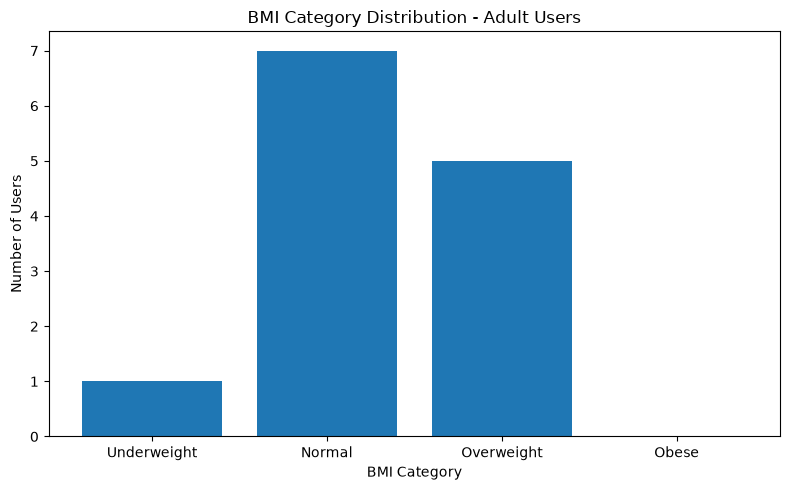

===== ADULT BMI ANALYSIS =====
Average BMI: 24.11
Minimum BMI: 18.03
Maximum BMI: 28.3

Average BMI by gender:
gender
Female    24.65
Male      23.77
Name: bmi, dtype: float64


In [97]:
import matplotlib.pyplot as plt

bmi_counts = (
    adult_users["bmi_category"]
    .value_counts()
    .reindex(["Underweight", "Normal", "Overweight", "Obese"], fill_value=0)
)

plt.figure(figsize=(8, 5))

plt.bar(
    bmi_counts.index,
    bmi_counts.values
)

plt.title("BMI Category Distribution - Adult Users")
plt.xlabel("BMI Category")
plt.ylabel("Number of Users")

plt.tight_layout()
plt.show()

print("===== ADULT BMI ANALYSIS =====")

print("Average BMI:",
      round(adult_users["bmi"].mean(), 2))

print("Minimum BMI:",
      round(adult_users["bmi"].min(), 2))

print("Maximum BMI:",
      round(adult_users["bmi"].max(), 2))

print("\nAverage BMI by gender:")
print(
    adult_users.groupby("gender")["bmi"]
    .mean()
    .round(2)
)

activity_level
Very active           2175.0
Extremely active      2038.0
Moderately active     1849.0
Lightly active        1363.0
Sedentary             1170.0
Name: daily_calorie_target, dtype: float64


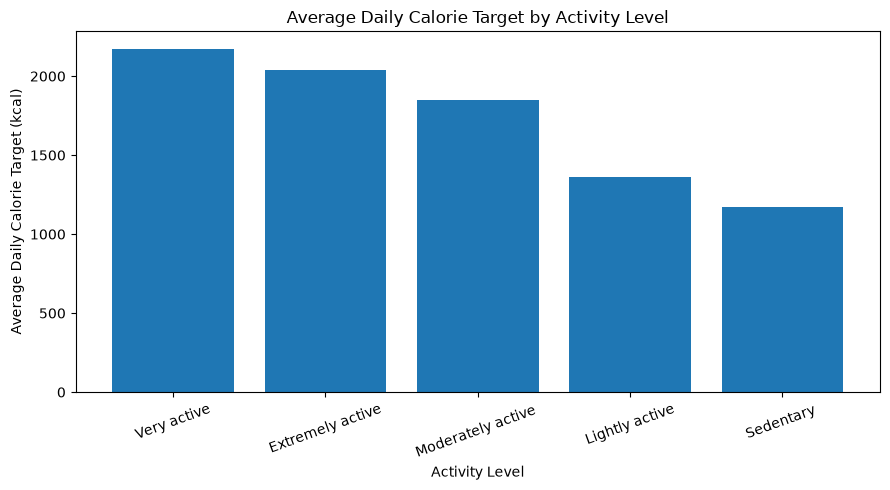

In [98]:
activity_calorie = (
    user.groupby("activity_level")["daily_calorie_target"]
    .mean()
    .sort_values(ascending=False)
    .round(0)
)

print(activity_calorie)

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    activity_calorie.index,
    activity_calorie.values
)

plt.title("Average Daily Calorie Target by Activity Level")
plt.xlabel("Activity Level")
plt.ylabel("Average Daily Calorie Target (kcal)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

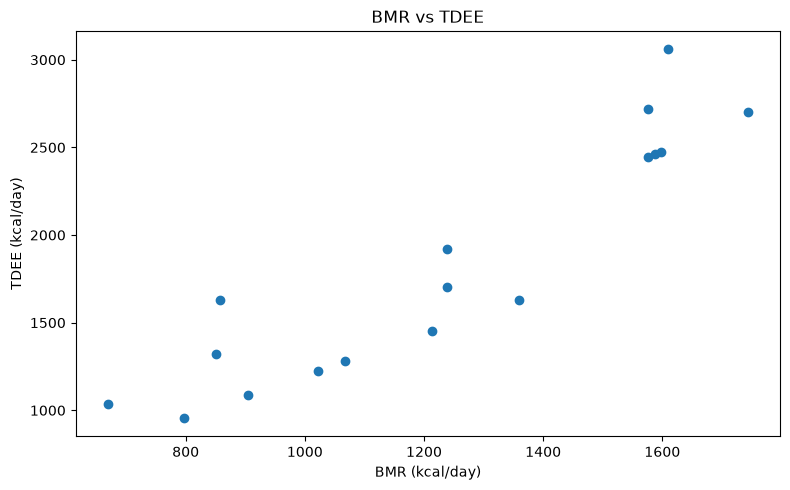

In [99]:
plt.figure(figsize=(8, 5))

plt.scatter(
    user["bmr"],
    user["tdee"]
)

plt.title("BMR vs TDEE")
plt.xlabel("BMR (kcal/day)")
plt.ylabel("TDEE (kcal/day)")

plt.tight_layout()
plt.show()

activity_level
Very active           2719.0
Extremely active      2344.0
Moderately active     2051.0
Lightly active        1704.0
Sedentary             1273.0
Name: tdee, dtype: float64


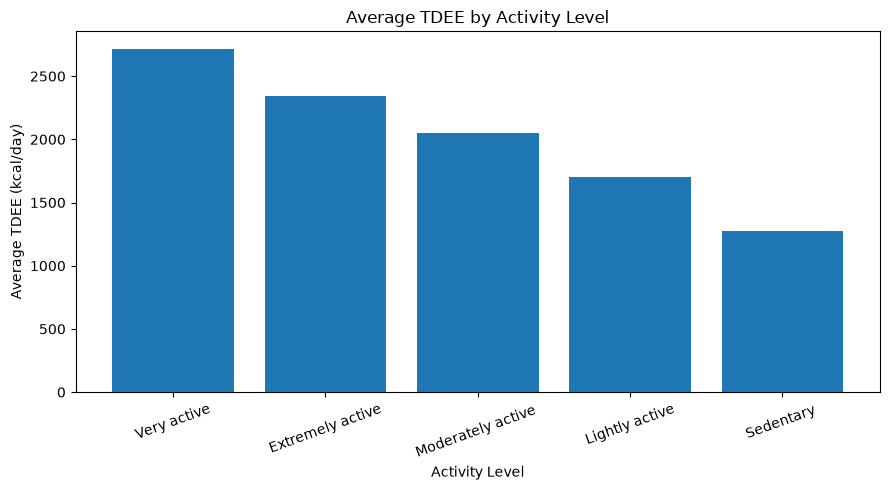

In [ ]:
#Activity level
activity_tdee = (
    user.groupby("activity_level")["tdee"]
    .mean()
    .sort_values(ascending=False)
    .round(0)
)

print(activity_tdee)

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    activity_tdee.index,
    activity_tdee.values
)

plt.title("Average TDEE by Activity Level")
plt.xlabel("Activity Level")
plt.ylabel("Average TDEE (kcal/day)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

#---------------------------------------------------------------------
# This chart lets you visually compare:
#Sedentary → Lightly active → Moderately active → Very active → Extremely active and their corresponding average TDEE.
#This is a stronger EDA question than 
# simply showing the activity counts because you're now examining a relationship between a categorical variable and a calculated numeric metric.
#----------------------------------------------------------------------------------

total_protein_g_perday     90.74
total_fat_g_perday         36.42
total_carb_g_perday       196.70
total_fibre_g_perday       47.17
dtype: float64


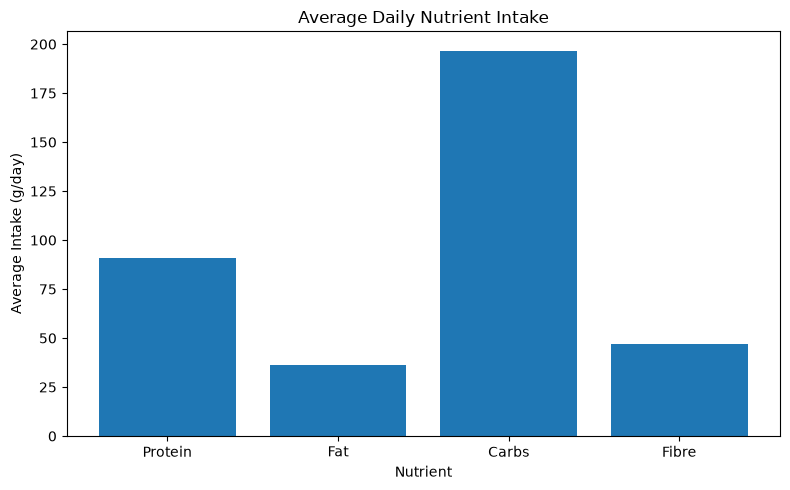

In [ ]:
#Average nutrient intake
nutrition_avg = (
    daily_summary[
        [
            "total_protein_g_perday",
            "total_fat_g_perday",
            "total_carb_g_perday",
            "total_fibre_g_perday"
        ]
    ]
    .mean()
    .round(2)
)

print(nutrition_avg)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    ["Protein", "Fat", "Carbs", "Fibre"],
    nutrition_avg.values
)

plt.title("Average Daily Nutrient Intake")
plt.xlabel("Nutrient")
plt.ylabel("Average Intake (g/day)")

plt.tight_layout()
plt.show()

#-------------------------------------------------------------------------
# This gives us a quick overall picture of the typical daily nutrition intake in the dataset.
#--------------------------------------------------------------------------

protein_consumed     90.72
protein_target      117.24
dtype: float64


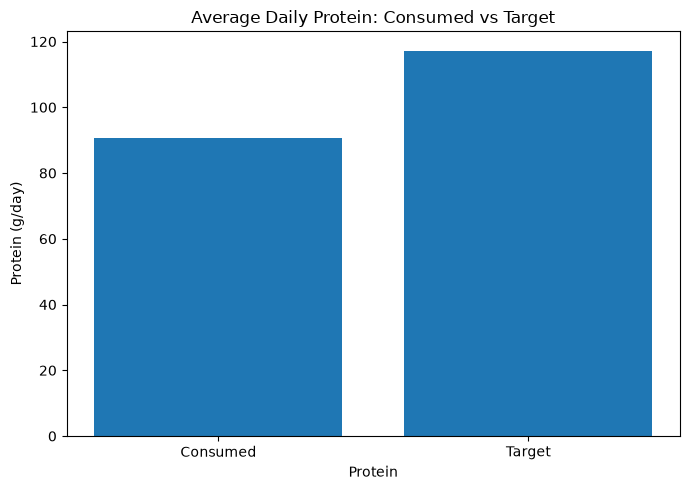

In [ ]:
#protein target
protein_comparison = (
    target_analysis[
        ["protein_consumed", "protein_target"]
    ]
    .mean()
    .round(2)
)

print(protein_comparison)

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    ["Consumed", "Target"],
    protein_comparison.values
)

plt.title("Average Daily Protein: Consumed vs Target")
plt.xlabel("Protein")
plt.ylabel("Protein (g/day)")

plt.tight_layout()
plt.show()

In [32]:
print([x for x in globals() if "target" in x.lower()])
print("user:", user.shape)
print("daily_summary:", daily_summary.shape)
print("target:", target.shape)

['target']
user: (17, 18)
daily_summary: (374, 9)
target: (374, 9)


fat_consumed    36.43
fat_target      49.00
dtype: float64


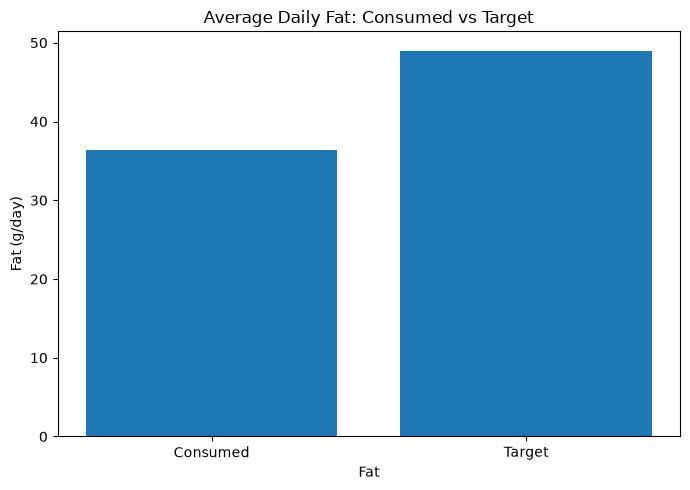

In [ ]:
#fat target
fat_comparison = (
    target_analysis[
        ["fat_consumed", "fat_target"]
    ]
    .mean()
    .round(2)
)

print(fat_comparison)

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    ["Consumed", "Target"],
    fat_comparison.values
)

plt.title("Average Daily Fat: Consumed vs Target")
plt.xlabel("Fat")
plt.ylabel("Fat (g/day)")

plt.tight_layout()
plt.show()

fibre_consumed    47.17
fibre_target      22.59
dtype: float64


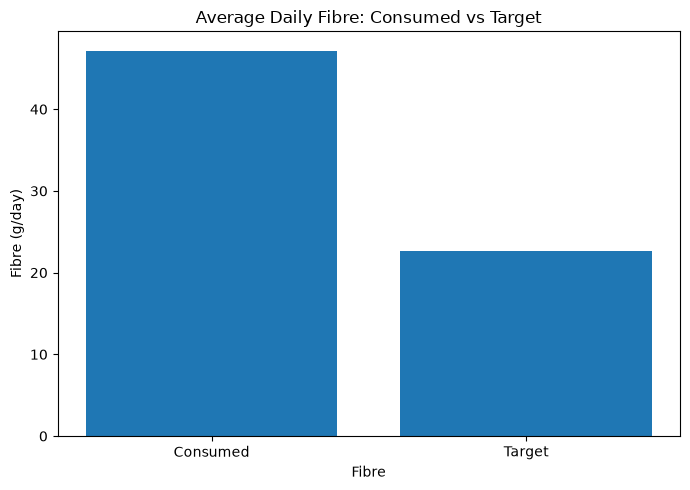

In [ ]:
#fibre target
fibre_comparison = (
    target_analysis[
        ["fibre_consumed", "fibre_target"]
    ]
    .mean()
    .round(2)
)

print(fibre_comparison)

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    ["Consumed", "Target"],
    fibre_comparison.values
)

plt.title("Average Daily Fibre: Consumed vs Target")
plt.xlabel("Fibre")
plt.ylabel("Fibre (g/day)")

plt.tight_layout()
plt.show()

carb_consumed    196.73
carb_target      110.06
dtype: float64


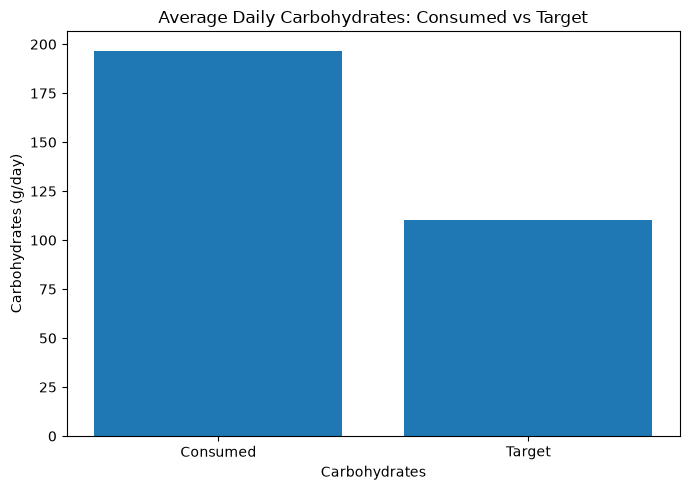

In [ ]:
#Carb target
carb_comparison = (
    target_analysis[
        ["carb_consumed", "carb_target"]
    ]
    .mean()
    .round(2)
)

print(carb_comparison)

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    ["Consumed", "Target"],
    carb_comparison.values
)

plt.title("Average Daily Carbohydrates: Consumed vs Target")
plt.xlabel("Carbohydrates")
plt.ylabel("Carbohydrates (g/day)")

plt.tight_layout()
plt.show()

calories_consumed    1478.0
calorie_target       1622.0
dtype: float64


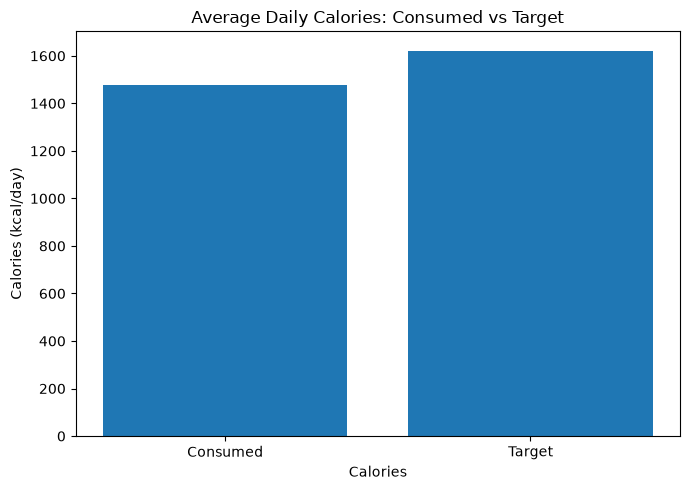

In [ ]:
#Calorie Target
calorie_comparison = (
    target_analysis[
        ["calories_consumed", "calorie_target"]
    ]
    .mean()
    .round(0)
)

print(calorie_comparison)

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    ["Consumed", "Target"],
    calorie_comparison.values
)

plt.title("Average Daily Calories: Consumed vs Target")
plt.xlabel("Calories")
plt.ylabel("Calories (kcal/day)")

plt.tight_layout()
plt.show()

{'Protein': np.float64(25.4), 'Fat': np.float64(28.6), 'Fibre': np.float64(92.0), 'Carbohydrates': np.float64(85.3), 'Calories': np.float64(34.5)}


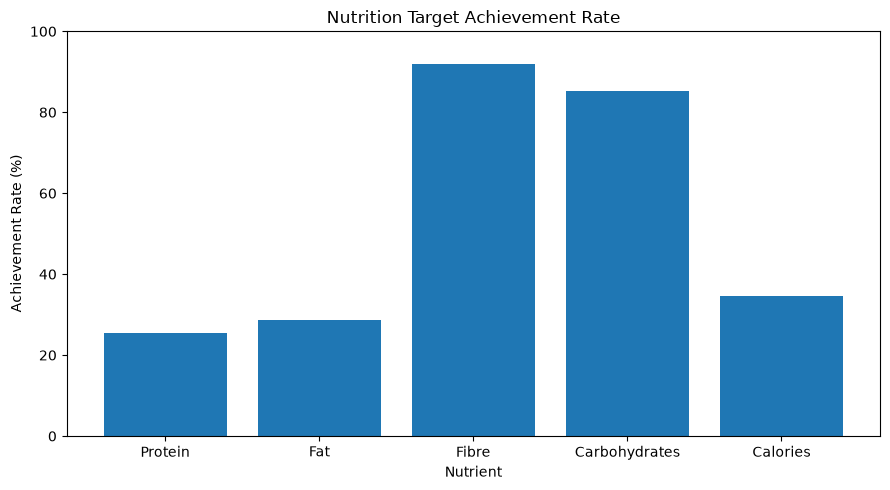

In [ ]:
# Target Achievement Rate (%)
achievement_rate = {
    "Protein": (
        target_analysis["protein_result"]
        .str.startswith("Achieved")
        .mean() * 100
    ),
    "Fat": (
        target_analysis["fat_result"]
        .str.startswith("Achieved")
        .mean() * 100
    ),
    "Fibre": (
        target_analysis["fibre_result"]
        .str.startswith("Achieved")
        .mean() * 100
    ),
    "Carbohydrates": (
        target_analysis["carb_result"]
        .str.startswith("Achieved")
        .mean() * 100
    ),
    "Calories": (
        target_analysis["calorie_result"]
        .str.startswith("Achieved")
        .mean() * 100
    )
}

achievement_rate = {
    k: round(v, 1)
    for k, v in achievement_rate.items()
}

print(achievement_rate)

plt.figure(figsize=(9, 5))

plt.bar(
    achievement_rate.keys(),
    achievement_rate.values()
)

plt.title("Nutrition Target Achievement Rate")
plt.xlabel("Nutrient")
plt.ylabel("Achievement Rate (%)")

plt.ylim(0, 100)
plt.tight_layout()
plt.show()

meal_type
Breakfast        1334
Dinner           1318
Lunch            1316
Evening Snack    1129
Mid snack        1122
Name: count, dtype: int64


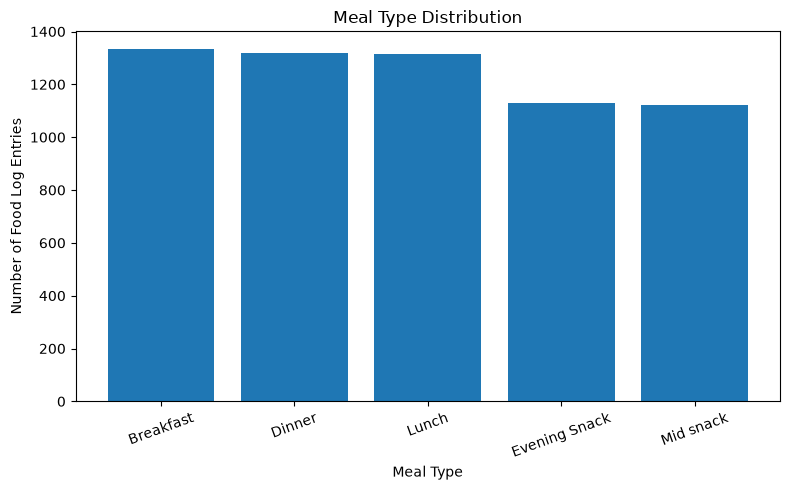

In [ ]:
#4.1 Meal Type Distribution
meal_counts = food_log["meal_type"].value_counts()

print(meal_counts)

plt.figure(figsize=(8, 5))

plt.bar(
    meal_counts.index,
    meal_counts.values
)

plt.title("Meal Type Distribution")
plt.xlabel("Meal Type")
plt.ylabel("Number of Food Log Entries")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

meal_type
Lunch            124.0
Dinner           107.0
Breakfast        106.0
Evening Snack     48.0
Mid snack         47.0
Name: total_calories_kcal, dtype: float64


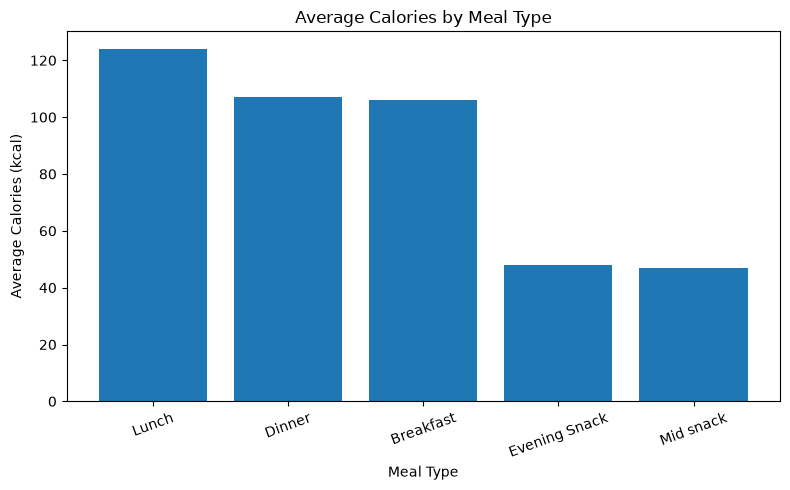

In [ ]:
# Average Calories by Meal Type.helps in Which meal type contributes the highest average calorie intake

meal_calories = (
    food_log
    .groupby("meal_type")["total_calories_kcal"]
    .mean()
    .sort_values(ascending=False)
    .round(0)
)

print(meal_calories)

plt.figure(figsize=(8, 5))

plt.bar(
    meal_calories.index,
    meal_calories.values
)

plt.title("Average Calories by Meal Type")
plt.xlabel("Meal Type")
plt.ylabel("Average Calories (kcal)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

meal_type
Lunch            7.8
Breakfast        7.1
Dinner           6.5
Mid snack        3.4
Evening Snack    1.6
Name: total_protein_g, dtype: float64


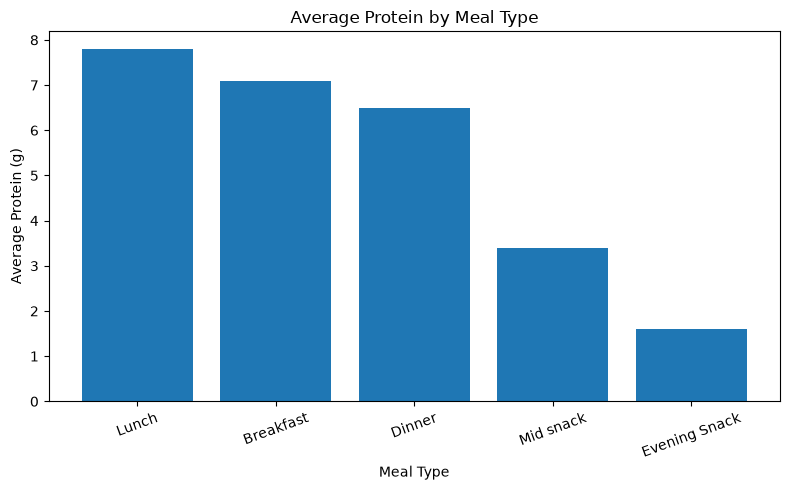

In [112]:
#protein acheived by meal type
meal_protein = (
    food_log
    .groupby("meal_type")["total_protein_g"]
    .mean()
    .sort_values(ascending=False)
    .round(1)
)

print(meal_protein)

plt.figure(figsize=(8, 5))

plt.bar(
    meal_protein.index,
    meal_protein.values
)

plt.title("Average Protein by Meal Type")
plt.xlabel("Meal Type")
plt.ylabel("Average Protein (g)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

meal_type
Lunch            3.3
Dinner           2.7
Breakfast        2.2
Mid snack        1.5
Evening Snack    1.0
Name: total_fat_g, dtype: float64


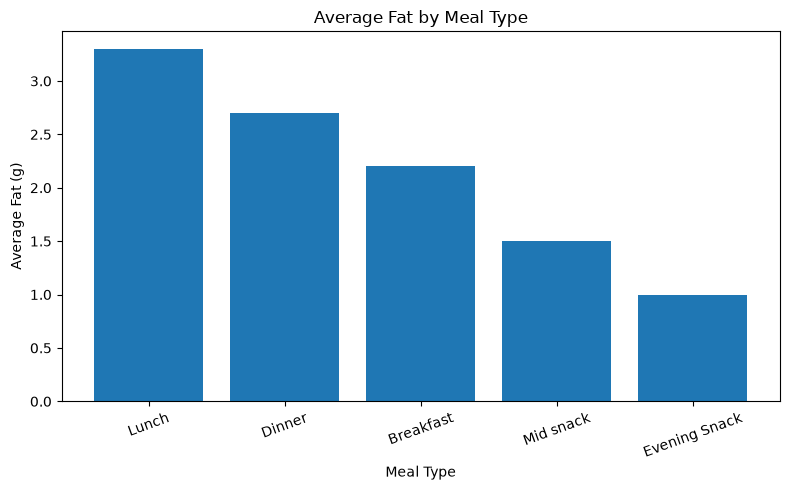

In [113]:
meal_fat = (
    food_log
    .groupby("meal_type")["total_fat_g"]
    .mean()
    .sort_values(ascending=False)
    .round(1)
)

print(meal_fat)

plt.figure(figsize=(8, 5))

plt.bar(
    meal_fat.index,
    meal_fat.values
)

plt.title("Average Fat by Meal Type")
plt.xlabel("Meal Type")
plt.ylabel("Average Fat (g)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

meal_type
Lunch            15.8
Breakfast        14.5
Dinner           14.2
Evening Snack     8.1
Mid snack         5.0
Name: total_carb_g, dtype: float64


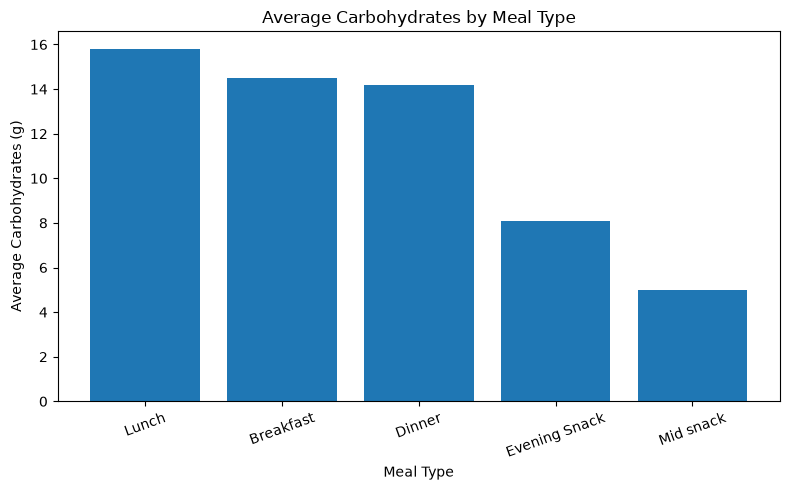

In [114]:
meal_carbs = (
    food_log
    .groupby("meal_type")["total_carb_g"]
    .mean()
    .sort_values(ascending=False)
    .round(1)
)

print(meal_carbs)

plt.figure(figsize=(8, 5))

plt.bar(
    meal_carbs.index,
    meal_carbs.values
)

plt.title("Average Carbohydrates by Meal Type")
plt.xlabel("Meal Type")
plt.ylabel("Average Carbohydrates (g)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [116]:
meal_nutrition = (
    food_log
    .groupby("meal_type")
    .agg(
        avg_calories=("total_calories_kcal", "mean"),
        avg_protein=("total_protein_g", "mean"),
        avg_fat=("total_fat_g", "mean"),
        avg_carbs=("total_carb_g", "mean"),
        avg_fibre=("total_fibre_g", "mean")
    )
    .round(1)
    .sort_values("avg_calories", ascending=False)
)

print(meal_nutrition)

achievement_counts = {}

for nutrient, column in {
    "Protein": "protein_result",
    "Fat": "fat_result",
    "Fibre": "fibre_result",
    "Carbohydrates": "carb_result",
    "Calories": "calorie_result"
}.items():

    achievement_counts[nutrient] = {
        "Achieved": target_analysis[column].str.startswith("Achieved").sum(),
        "Not Achieved": target_analysis[column].str.startswith("Not Achieved").sum()
    }

achievement_counts = pd.DataFrame(achievement_counts).T

print(achievement_counts)

               avg_calories  avg_protein  avg_fat  avg_carbs  avg_fibre
meal_type                                                              
Lunch                 124.1          7.8      3.3       15.8        3.7
Dinner                106.8          6.5      2.7       14.2        3.4
Breakfast             106.3          7.1      2.2       14.5        3.2
Evening Snack          47.6          1.6      1.0        8.1        1.8
Mid snack              47.2          3.4      1.5        5.0        1.7
               Achieved  Not Achieved
Protein              95           279
Fat                 107           267
Fibre               344            30
Carbohydrates       319            55
Calories            129           245


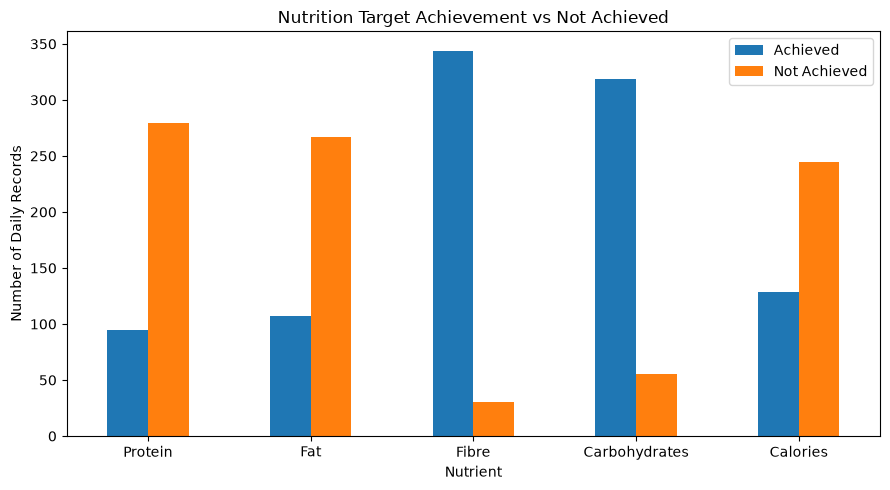

In [117]:
achievement_counts.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Nutrition Target Achievement vs Not Achieved")
plt.xlabel("Nutrient")
plt.ylabel("Number of Daily Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
user_achievement = (
    target_analysis
    .assign(
        protein_achieved=target_analysis["protein_result"].str.startswith("Achieved"),
        fat_achieved=target_analysis["fat_result"].str.startswith("Achieved"),
        fibre_achieved=target_analysis["fibre_result"].str.startswith("Achieved"),
        carb_achieved=target_analysis["carb_result"].str.startswith("Achieved"),
        calorie_achieved=target_analysis["calorie_result"].str.startswith("Achieved")
    )
    .groupby("user_id")
    .agg(
        protein_rate=("protein_achieved", "mean"),
        fat_rate=("fat_achieved", "mean"),
        fibre_rate=("fibre_achieved", "mean"),
        carb_rate=("carb_achieved", "mean"),
        calorie_rate=("calorie_achieved", "mean")
    )
    .mul(100)
    .round(1)
)

print(user_achievement)



         protein_rate  fat_rate  fibre_rate  carb_rate  calorie_rate
user_id                                                             
HM001            40.9      40.9        95.5      100.0          36.4
HM002             4.5       9.1        86.4       81.8          40.9
HM003            31.8       0.0        81.8       45.5          22.7
HM004            18.2      18.2       100.0       90.9          36.4
HM005            13.6      45.5        95.5      100.0          22.7
HM006            45.5      18.2        86.4       81.8          36.4
HM007            40.9      31.8        95.5       90.9          36.4
HM008            18.2      22.7       100.0       81.8          40.9
HM009            22.7       0.0        95.5       50.0          45.5
HM010            45.5      50.0        86.4       95.5          50.0
HM011            31.8       4.5        81.8       72.7          27.3
HM012             9.1      22.7        86.4       86.4          36.4
HM013            36.4      68.2   

In [120]:
user_achievement["overall_rate"] = (
    user_achievement.mean(axis=1)
    .round(1)
)

user_achievement = user_achievement.sort_values(
    "overall_rate",
    ascending=False
)

print(user_achievement)

         protein_rate  fat_rate  fibre_rate  carb_rate  calorie_rate  \
user_id                                                                
HM017             9.1     100.0        90.9      100.0          27.3   
HM010            45.5      50.0        86.4       95.5          50.0   
HM001            40.9      40.9        95.5      100.0          36.4   
HM014            31.8      40.9       100.0       95.5          45.5   
HM013            36.4      68.2        86.4      100.0           9.1   
HM007            40.9      31.8        95.5       90.9          36.4   
HM005            13.6      45.5        95.5      100.0          22.7   
HM006            45.5      18.2        86.4       81.8          36.4   
HM004            18.2      18.2       100.0       90.9          36.4   
HM008            18.2      22.7       100.0       81.8          40.9   
HM016            22.7       9.1       100.0       90.9          31.8   
HM012             9.1      22.7        86.4       86.4          

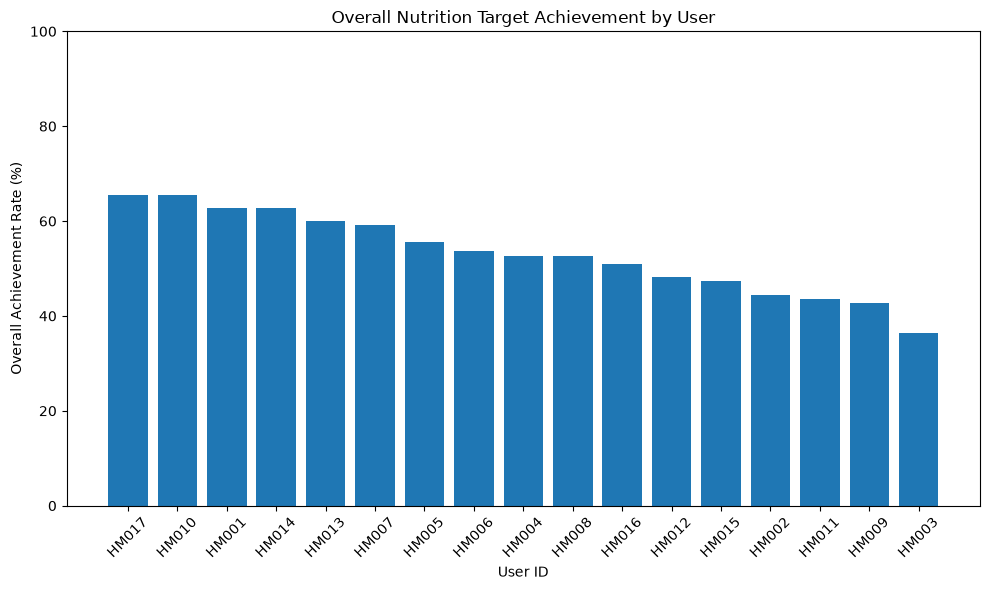

In [121]:
plt.figure(figsize=(10, 6))

plt.bar(
    user_achievement.index,
    user_achievement["overall_rate"]
)

plt.title("Overall Nutrition Target Achievement by User")
plt.xlabel("User ID")
plt.ylabel("Overall Achievement Rate (%)")

plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

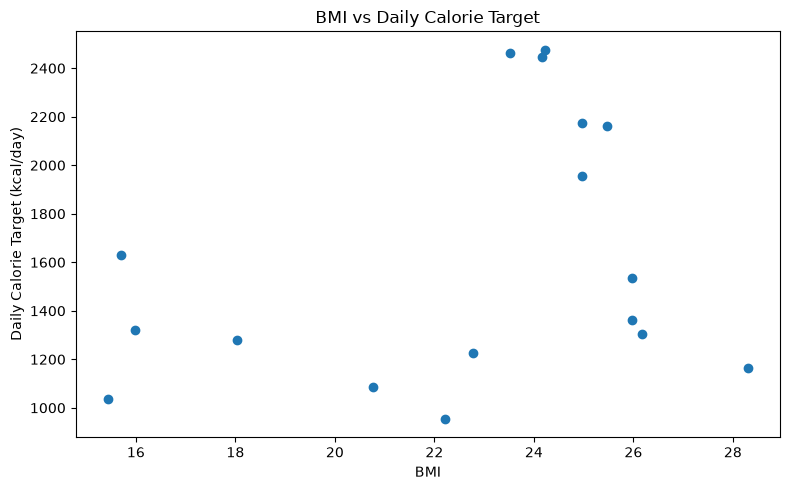

In [122]:
plt.figure(figsize=(8, 5))

plt.scatter(
    user["bmi"],
    user["daily_calorie_target"]
)

plt.title("BMI vs Daily Calorie Target")
plt.xlabel("BMI")
plt.ylabel("Daily Calorie Target (kcal/day)")

plt.tight_layout()
plt.show()

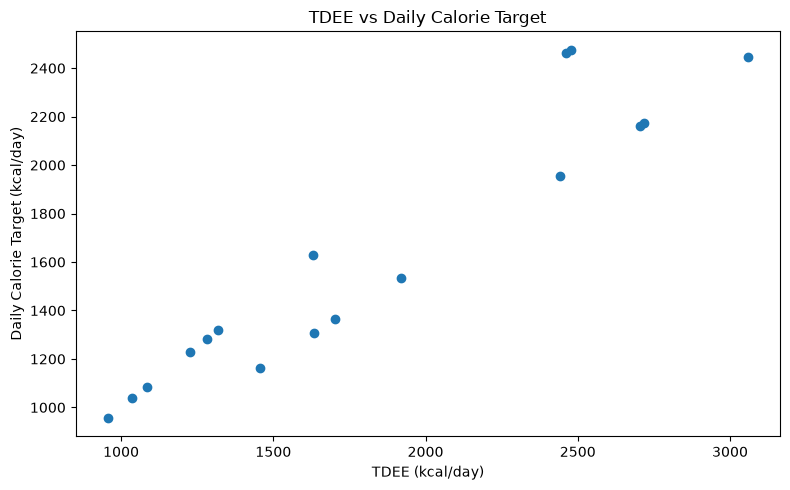

In [123]:
plt.figure(figsize=(8, 5))

plt.scatter(
    user["tdee"],
    user["daily_calorie_target"]
)

plt.title("TDEE vs Daily Calorie Target")
plt.xlabel("TDEE (kcal/day)")
plt.ylabel("Daily Calorie Target (kcal/day)")

plt.tight_layout()
plt.show()

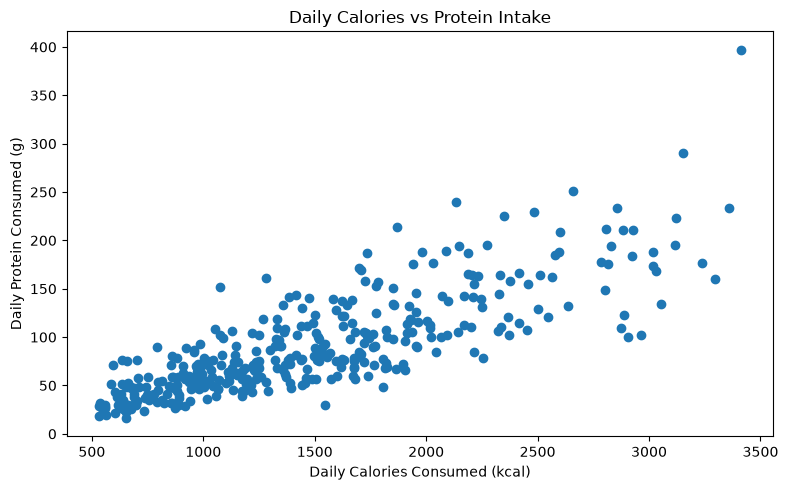

In [124]:
plt.figure(figsize=(8, 5))

plt.scatter(
    target_analysis["calories_consumed"],
    target_analysis["protein_consumed"]
)

plt.title("Daily Calories vs Protein Intake")
plt.xlabel("Daily Calories Consumed (kcal)")
plt.ylabel("Daily Protein Consumed (g)")

plt.tight_layout()
plt.show()

In [125]:
correlation = (
    target_analysis["calories_consumed"]
    .corr(target_analysis["protein_consumed"])
)

print("Correlation between Calories and Protein:", round(correlation, 3))

Correlation between Calories and Protein: 0.811


activity_level
Very active           2719.0
Extremely active      2344.0
Moderately active     2051.0
Lightly active        1704.0
Sedentary             1273.0
Name: tdee, dtype: float64


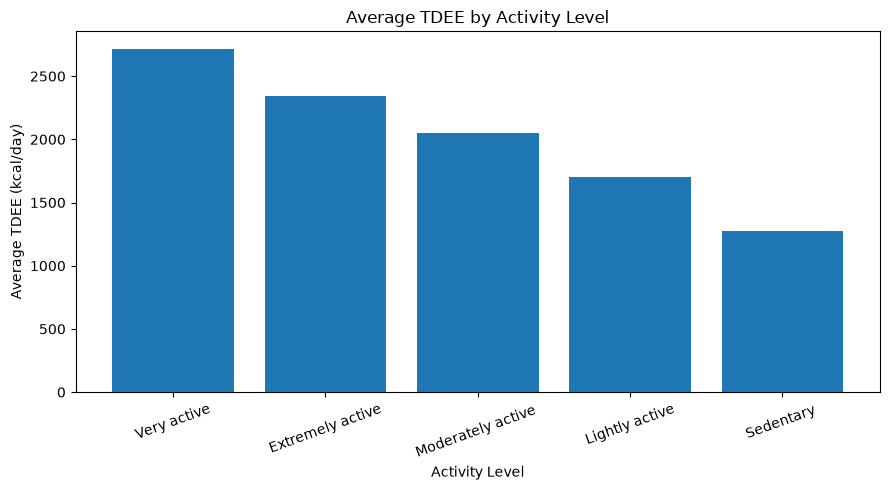

In [126]:
activity_tdee = (
    user
    .groupby("activity_level")["tdee"]
    .mean()
    .sort_values(ascending=False)
    .round(0)
)

print(activity_tdee)

plt.figure(figsize=(9, 5))

plt.bar(
    activity_tdee.index,
    activity_tdee.values
)

plt.title("Average TDEE by Activity Level")
plt.xlabel("Activity Level")
plt.ylabel("Average TDEE (kcal/day)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [127]:
target_analysis["calorie_difference"] = (
    target_analysis["calories_consumed"]
    - target_analysis["calorie_target"]
)

print(
    target_analysis[
        [
            "user_id",
            "target_date",
            "calories_consumed",
            "calorie_target",
            "calorie_difference"
        ]
    ].head(10)
)

  user_id target_date  calories_consumed  calorie_target  calorie_difference
0   HM001  2026-08-01             1927.0            1536               391.0
1   HM001  2026-08-02             1389.0            1536              -147.0
2   HM001  2026-08-03             1464.0            1536               -72.0
3   HM001  2026-08-04             1001.0            1536              -535.0
4   HM001  2026-08-05             1937.0            1536               401.0
5   HM001  2026-08-06             1863.0            1536               327.0
6   HM001  2026-08-07              753.0            1536              -783.0
7   HM001  2026-08-08             1362.0            1536              -174.0
8   HM001  2026-08-09             1853.0            1536               317.0
9   HM001  2026-08-10              988.0            1536              -548.0


In [128]:
target_analysis["calorie_difference_pct"] = (
    target_analysis["calorie_difference"]
    / target_analysis["calorie_target"]
    * 100
).round(1)

print(
    target_analysis[
        [
            "user_id",
            "target_date",
            "calorie_difference",
            "calorie_difference_pct"
        ]
    ].head(10)
)

  user_id target_date  calorie_difference  calorie_difference_pct
0   HM001  2026-08-01               391.0                    25.5
1   HM001  2026-08-02              -147.0                    -9.6
2   HM001  2026-08-03               -72.0                    -4.7
3   HM001  2026-08-04              -535.0                   -34.8
4   HM001  2026-08-05               401.0                    26.1
5   HM001  2026-08-06               327.0                    21.3
6   HM001  2026-08-07              -783.0                   -51.0
7   HM001  2026-08-08              -174.0                   -11.3
8   HM001  2026-08-09               317.0                    20.6
9   HM001  2026-08-10              -548.0                   -35.7


In [129]:
target_analysis["protein_gap"] = (
    target_analysis["protein_consumed"]
    - target_analysis["protein_target"]
).round(1)

target_analysis["fat_gap"] = (
    target_analysis["fat_consumed"]
    - target_analysis["fat_target"]
).round(1)

target_analysis["fibre_gap"] = (
    target_analysis["fibre_consumed"]
    - target_analysis["fibre_target"]
).round(1)

target_analysis["carb_gap"] = (
    target_analysis["carb_consumed"]
    - target_analysis["carb_target"]
).round(1)

In [130]:
print(
    target_analysis[
        [
            "user_id",
            "target_date",
            "protein_gap",
            "fat_gap",
            "fibre_gap",
            "carb_gap"
        ]
    ].head(10)
)

  user_id target_date  protein_gap  fat_gap  fibre_gap  carb_gap
0   HM001  2026-08-01         33.8     -7.2       39.0     210.0
1   HM001  2026-08-02        -12.5      2.7        2.0      97.0
2   HM001  2026-08-03        -17.9     -6.1       12.0     142.0
3   HM001  2026-08-04         -9.7    -11.3       -1.0      29.0
4   HM001  2026-08-05         20.0     13.2       38.0     177.0
5   HM001  2026-08-06        -17.7     27.0       43.0     169.0
6   HM001  2026-08-07        -25.8    -18.8       10.0       0.0
7   HM001  2026-08-08         20.2     -5.9       45.0      77.0
8   HM001  2026-08-09         13.5     14.5       17.0     162.0
9   HM001  2026-08-10        -28.1    -21.3       18.0      67.0


protein_gap   -26.5
fat_gap       -12.6
fibre_gap      24.6
carb_gap       86.7
dtype: float64


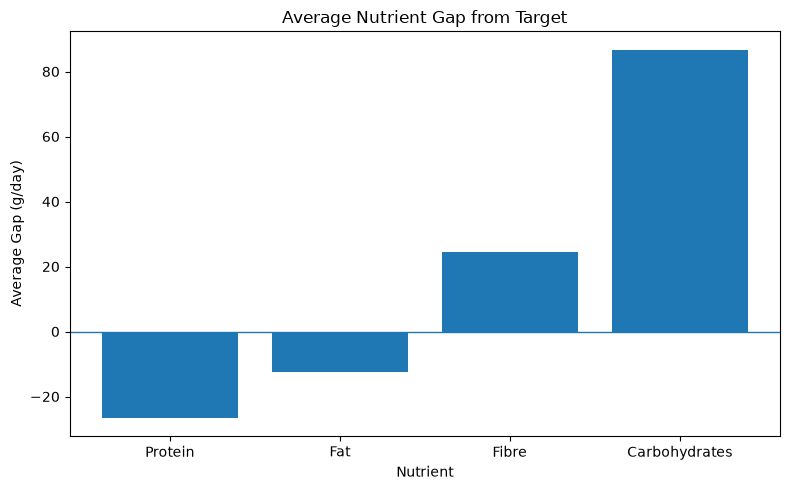

In [ ]:
average_gaps = (
    target_analysis[
        [
            "protein_gap",
            "fat_gap",
            "fibre_gap",
            "carb_gap"
        ]
    ]
    .mean()
    .round(1)
)

print(average_gaps)

plt.figure(figsize=(8, 5))

plt.bar(
    ["Protein", "Fat", "Fibre", "Carbohydrates"],
    average_gaps.values
)

plt.title("Average Nutrient Gap from Target")
plt.xlabel("Nutrient")
plt.ylabel("Average Gap (g/day)")

plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()

'''Across 374 daily records, average protein and fat consumption were below personalized targets, 
while fibre and carbohydrate consumption were above their respective targets.
'''


In [ ]:
target_analysis["calorie_adherence"] = np.select(
    [
        target_analysis["calorie_difference_pct"] < -10,
        target_analysis["calorie_difference_pct"].between(-10, 10),
        target_analysis["calorie_difference_pct"] > 10
    ],
    [
        "Below Target",
        "Within ±10%",
        "Above Target"
)

print(target_analysis["calorie_adherence"].value_counts())

adherence_counts = (
    target_analysis["calorie_adherence"]
    .value_counts()
    .reindex(
        ["Below Target", "Within ±10%", "Above Target"],
        fill_value=0
    )
)

plt.figure(figsize=(8, 5))

plt.bar(
    adherence_counts.index,
    adherence_counts.values
)

plt.title("Daily Calorie Adherence Distribution")
plt.xlabel("Calorie Adherence")
plt.ylabel("Number of Daily Records")

plt.tight_layout()
plt.show()